In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mpt
import seaborn as sn
import warnings
warnings.filterwarnings("ignore")

In [54]:
df = pd.read_excel("EastWestAirlines.xlsx", sheet_name= "data")
df

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0


In [55]:
df = df.drop(["ID#","Award?"], axis = 1)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Balance            3999 non-null   int64
 1   Qual_miles         3999 non-null   int64
 2   cc1_miles          3999 non-null   int64
 3   cc2_miles          3999 non-null   int64
 4   cc3_miles          3999 non-null   int64
 5   Bonus_miles        3999 non-null   int64
 6   Bonus_trans        3999 non-null   int64
 7   Flight_miles_12mo  3999 non-null   int64
 8   Flight_trans_12    3999 non-null   int64
 9   Days_since_enroll  3999 non-null   int64
dtypes: int64(10)
memory usage: 312.6 KB


In [57]:
df.isnull().sum()

Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
dtype: int64

In [58]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
3994    False
3995    False
3996    False
3997    False
3998    False
Length: 3999, dtype: bool

In [59]:
df.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
count,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000
mean,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939
std,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454
min,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000
25%,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000
50%,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000
75%,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000
max,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000


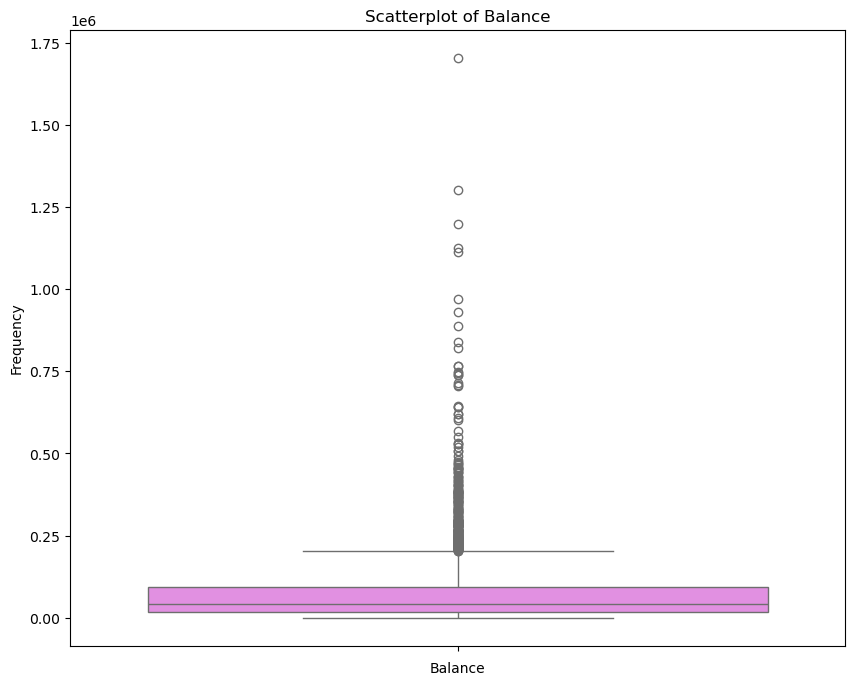

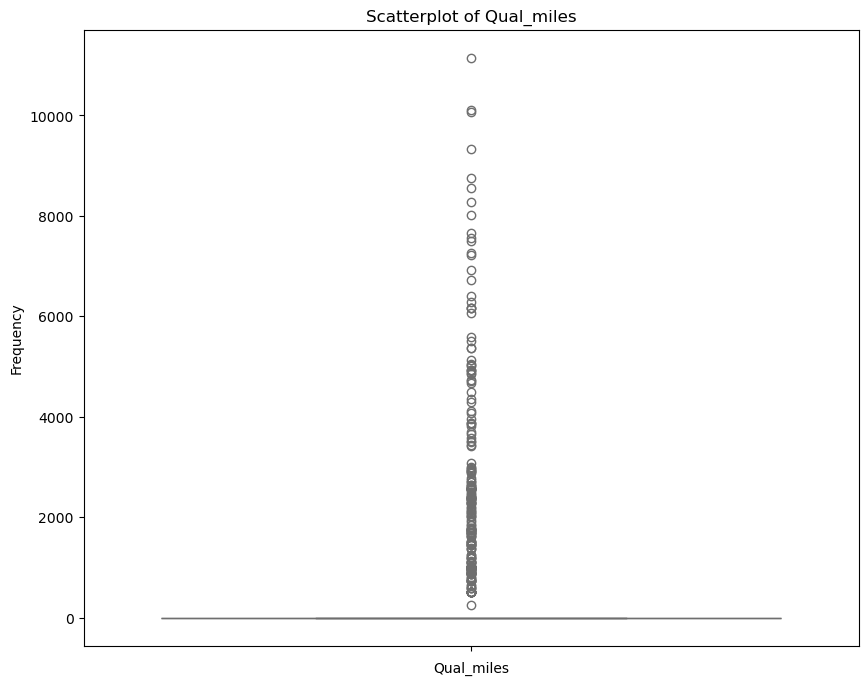

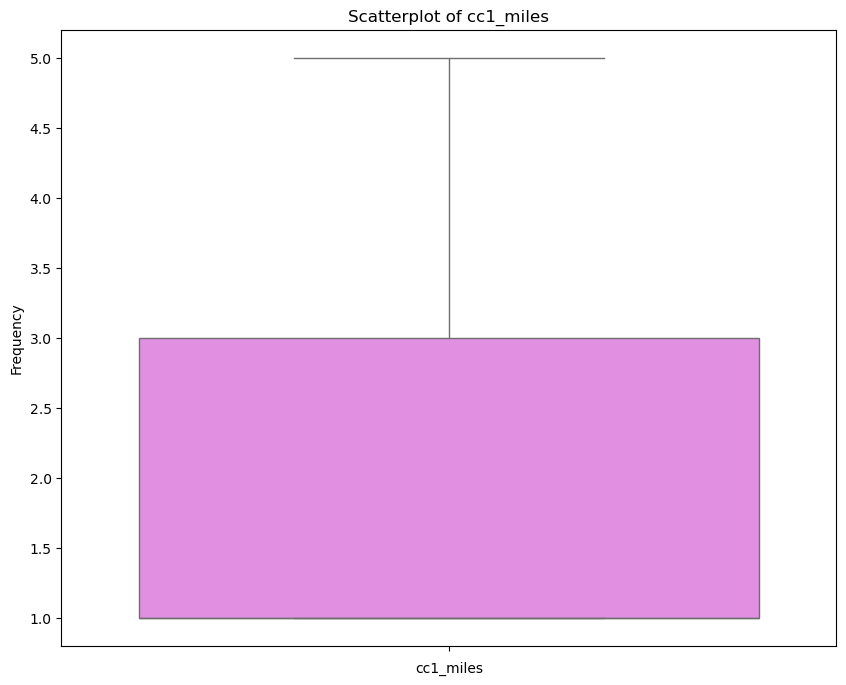

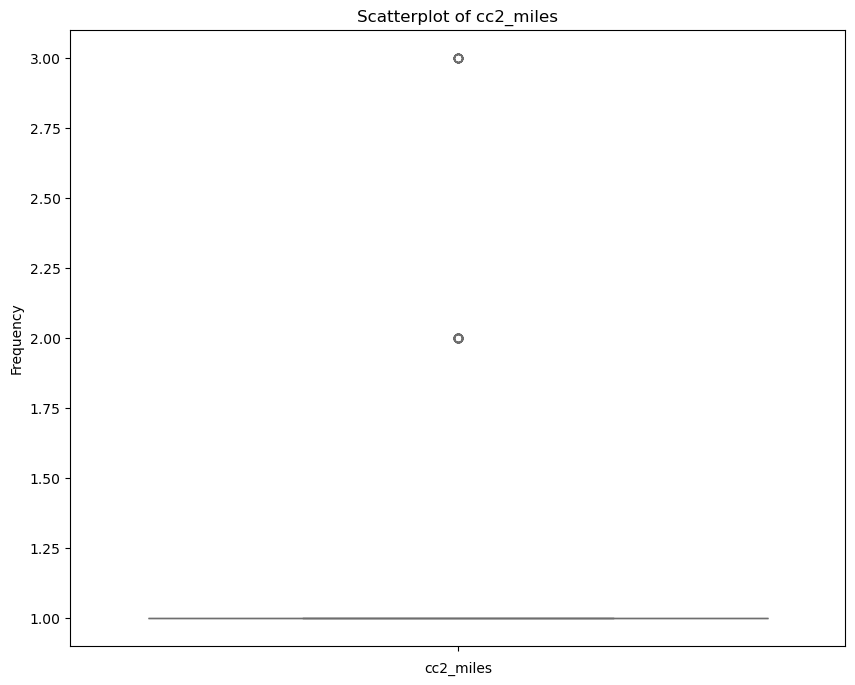

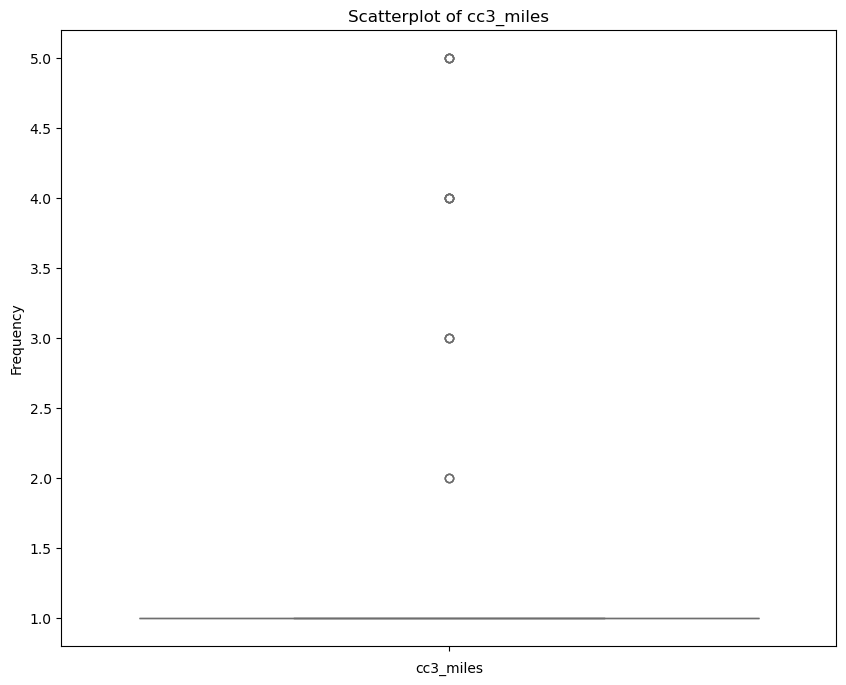

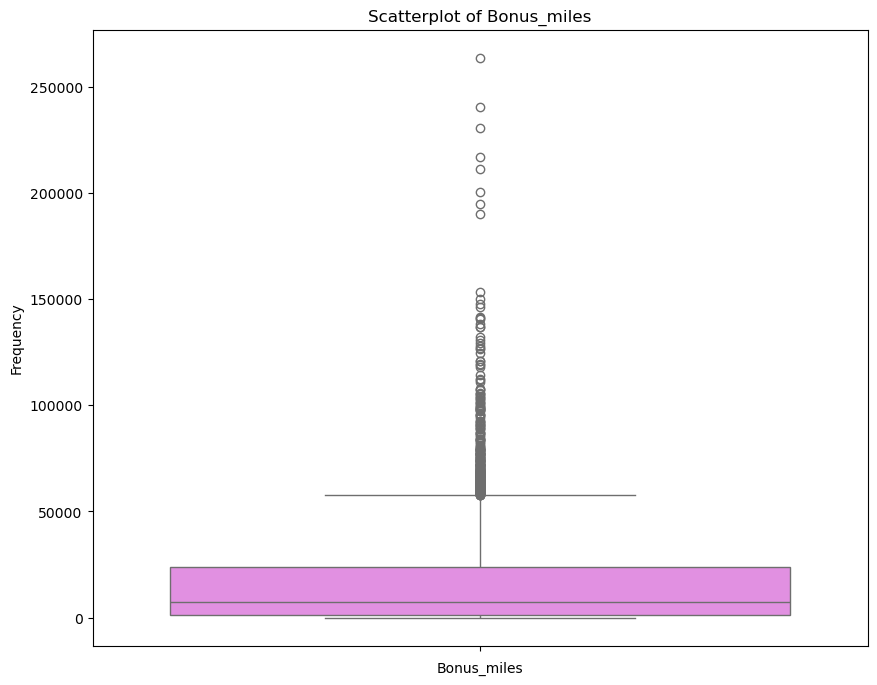

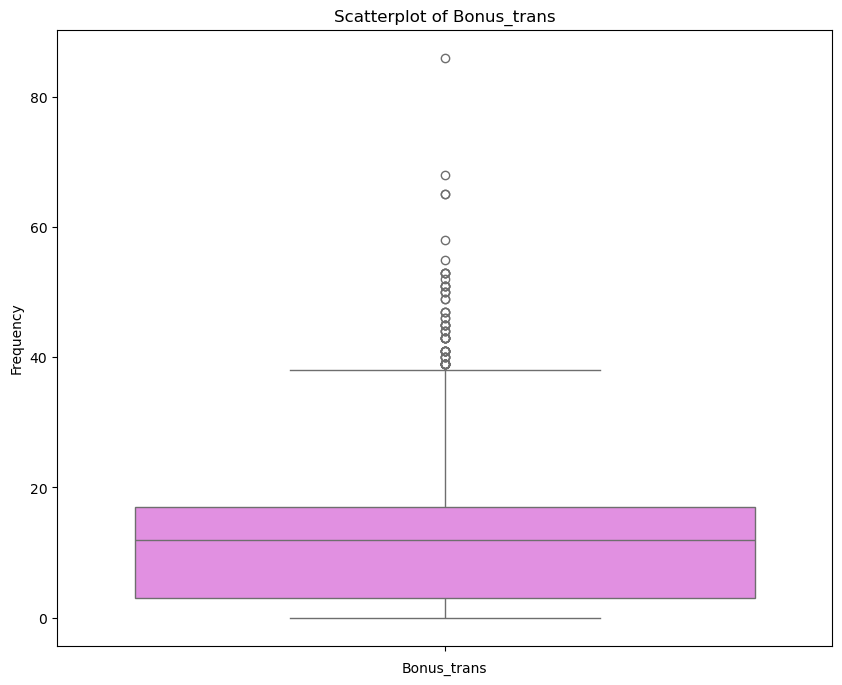

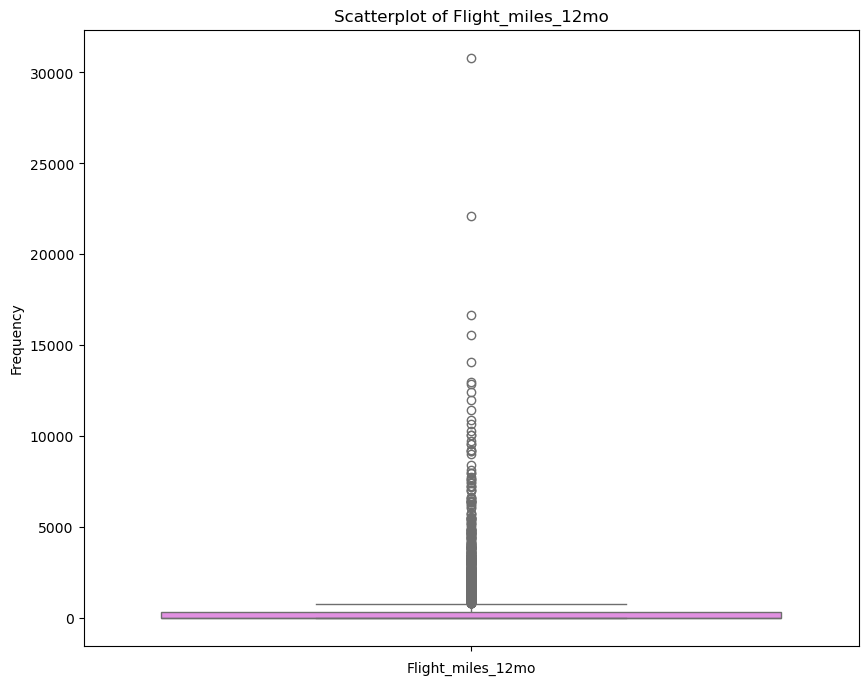

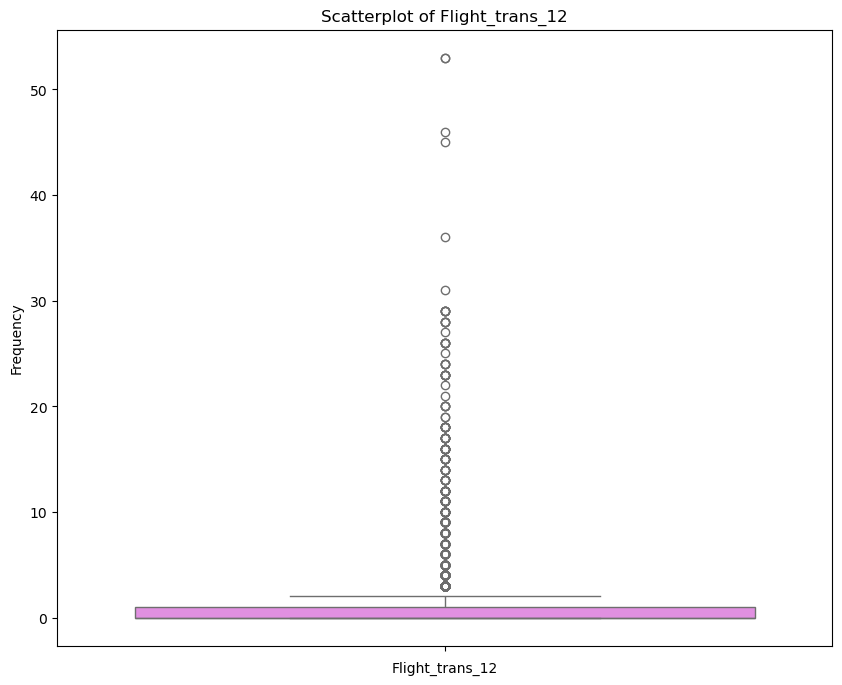

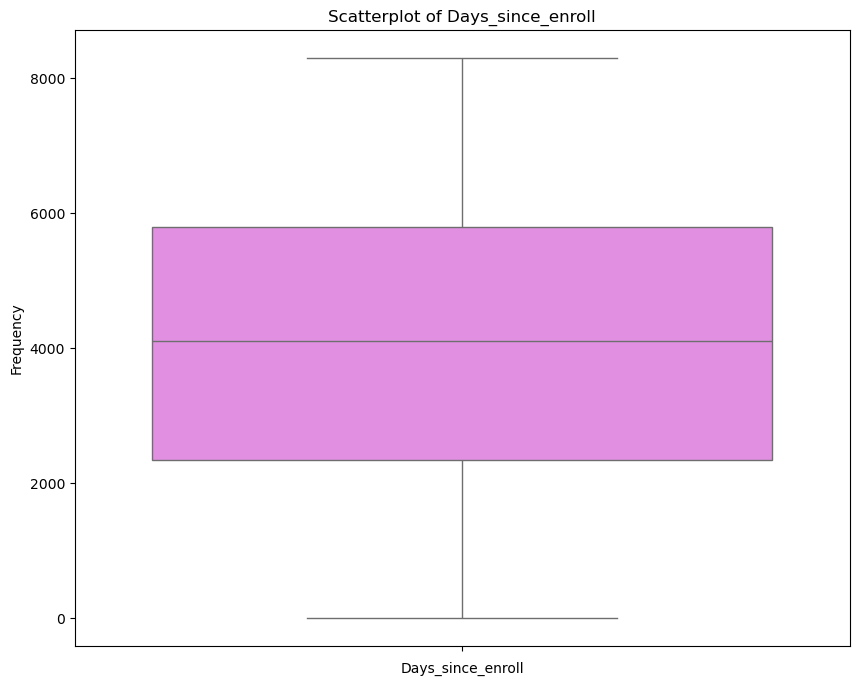

In [60]:
for n in df.columns:
    mpt.figure(figsize=(10,8))
    sn.boxplot(data = df[n] ,color = "violet")
    mpt.title(f"Scatterplot of {n}")
    mpt.xlabel(n)
    mpt.ylabel("Frequency")
    mpt.show()

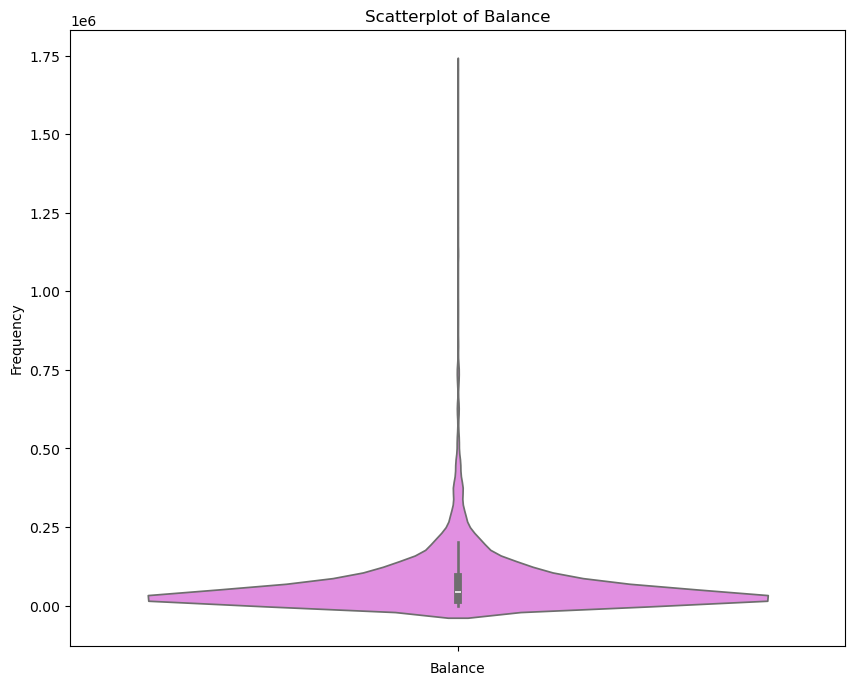

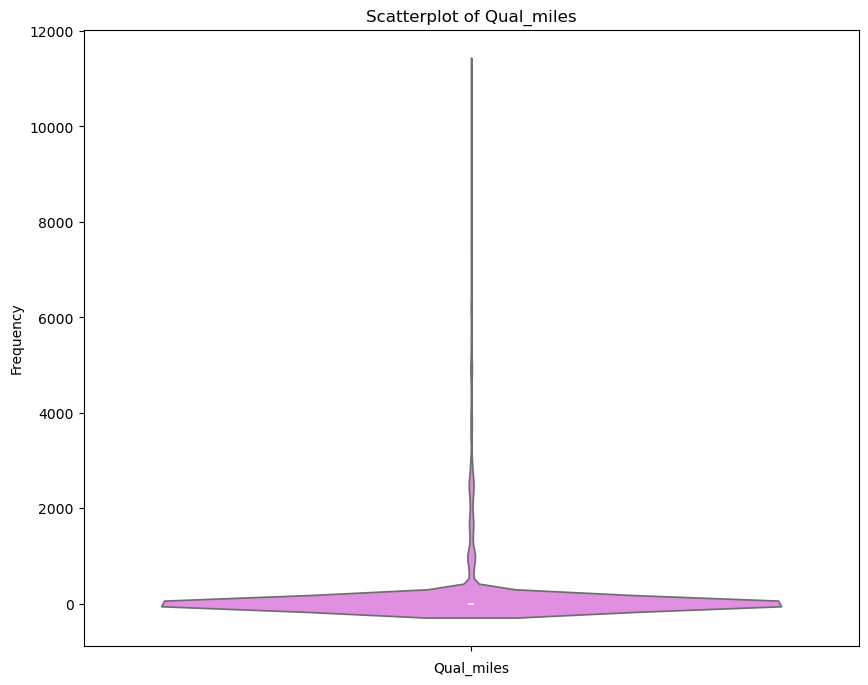

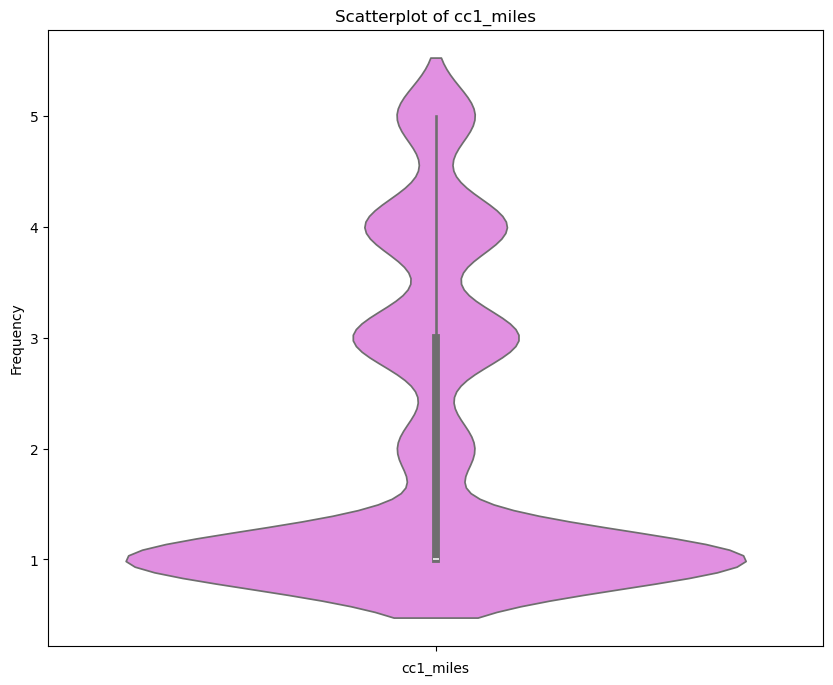

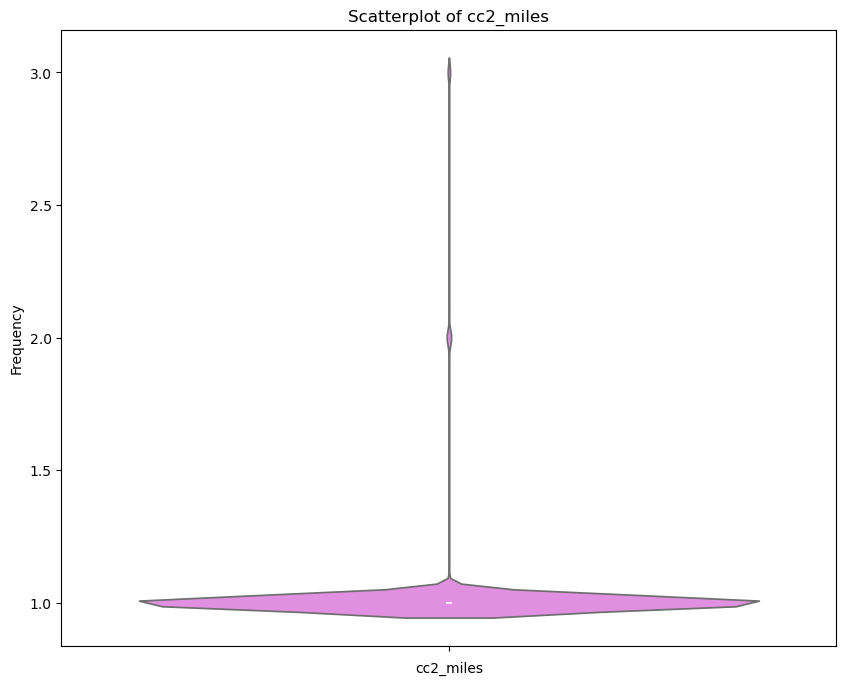

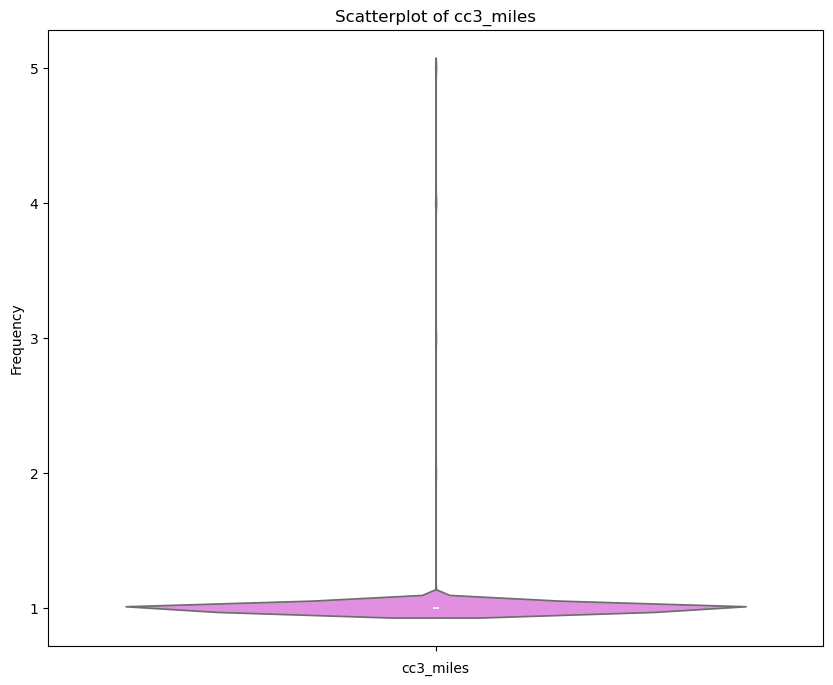

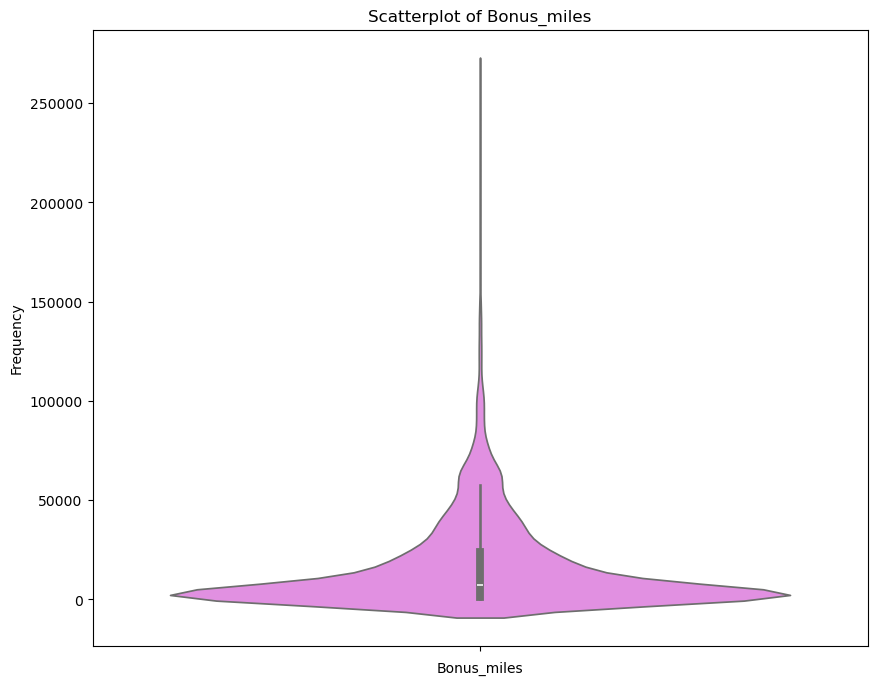

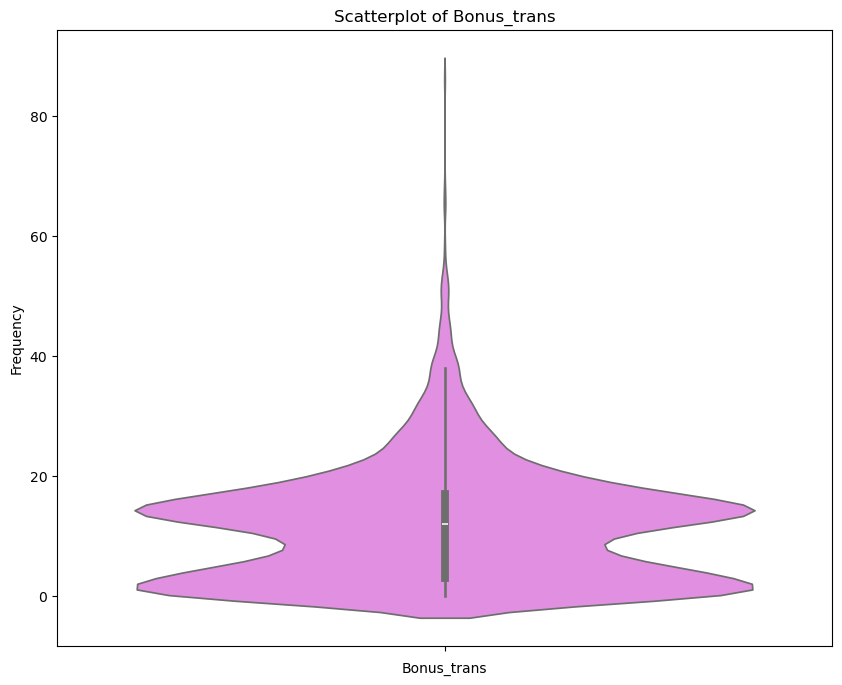

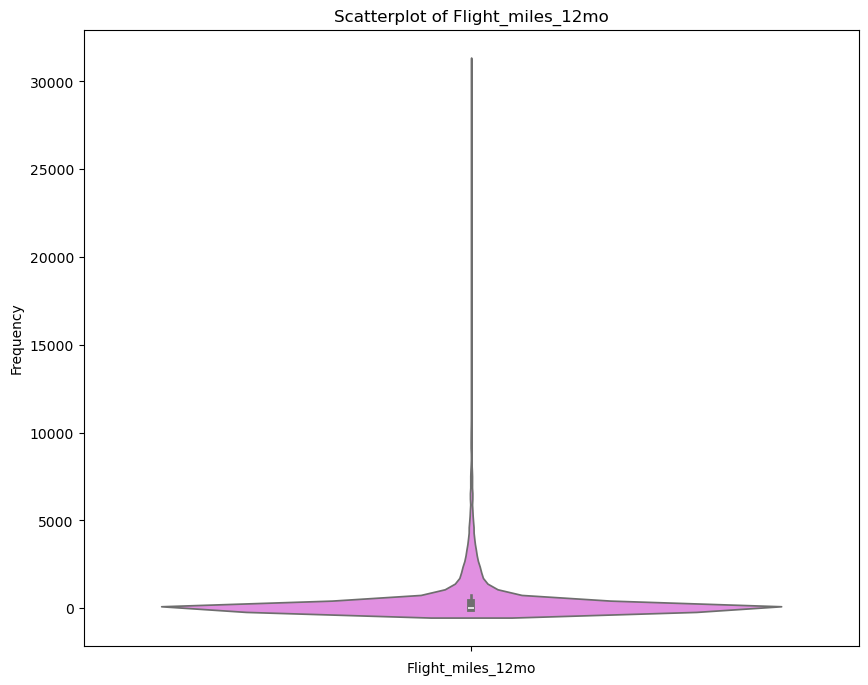

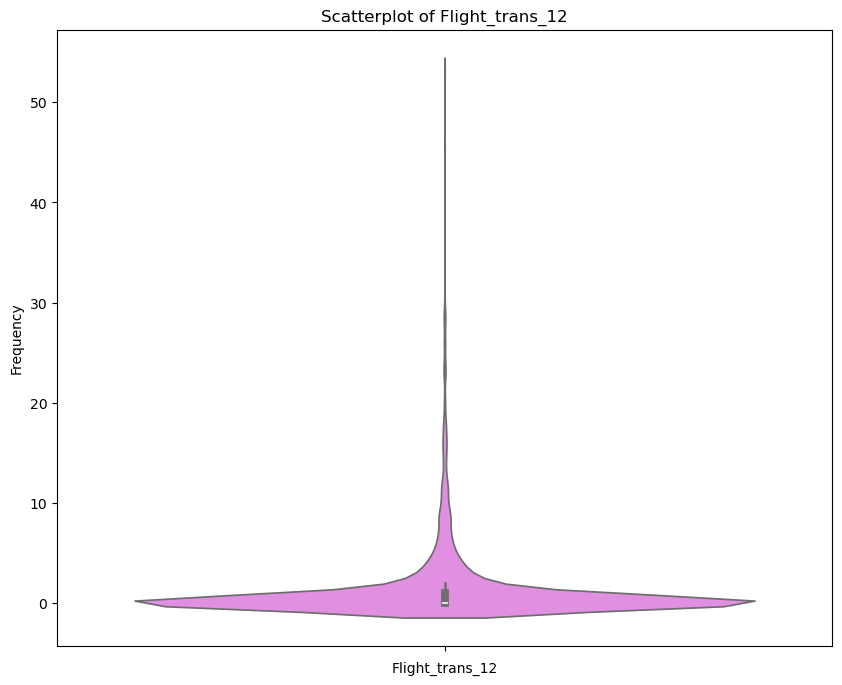

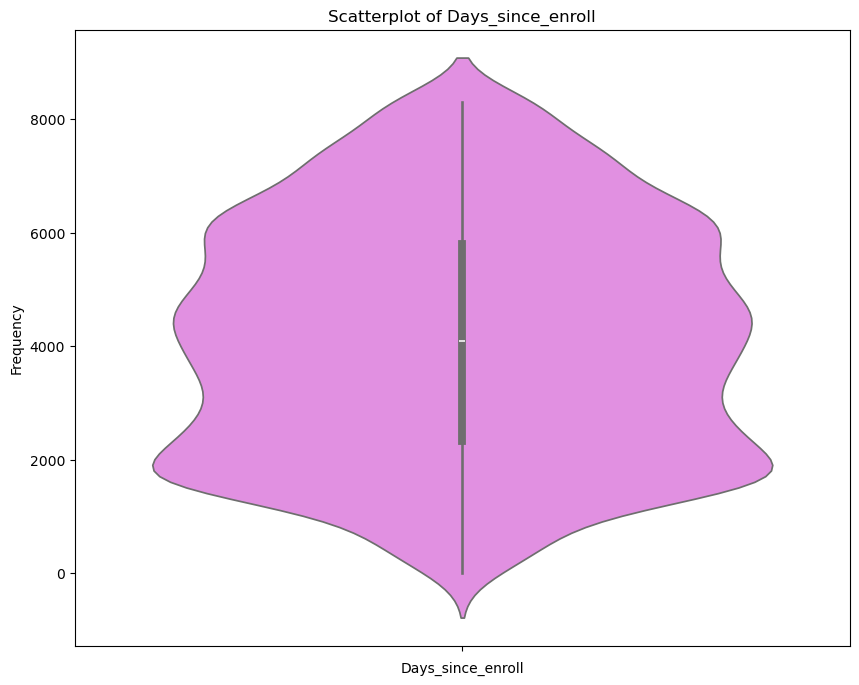

In [61]:
for n in df.columns:
    mpt.figure(figsize=(10,8))
    sn.violinplot(data = df[n] ,color = "violet")
    mpt.title(f"Scatterplot of {n}")
    mpt.xlabel(n)
    mpt.ylabel("Frequency")
    mpt.show()

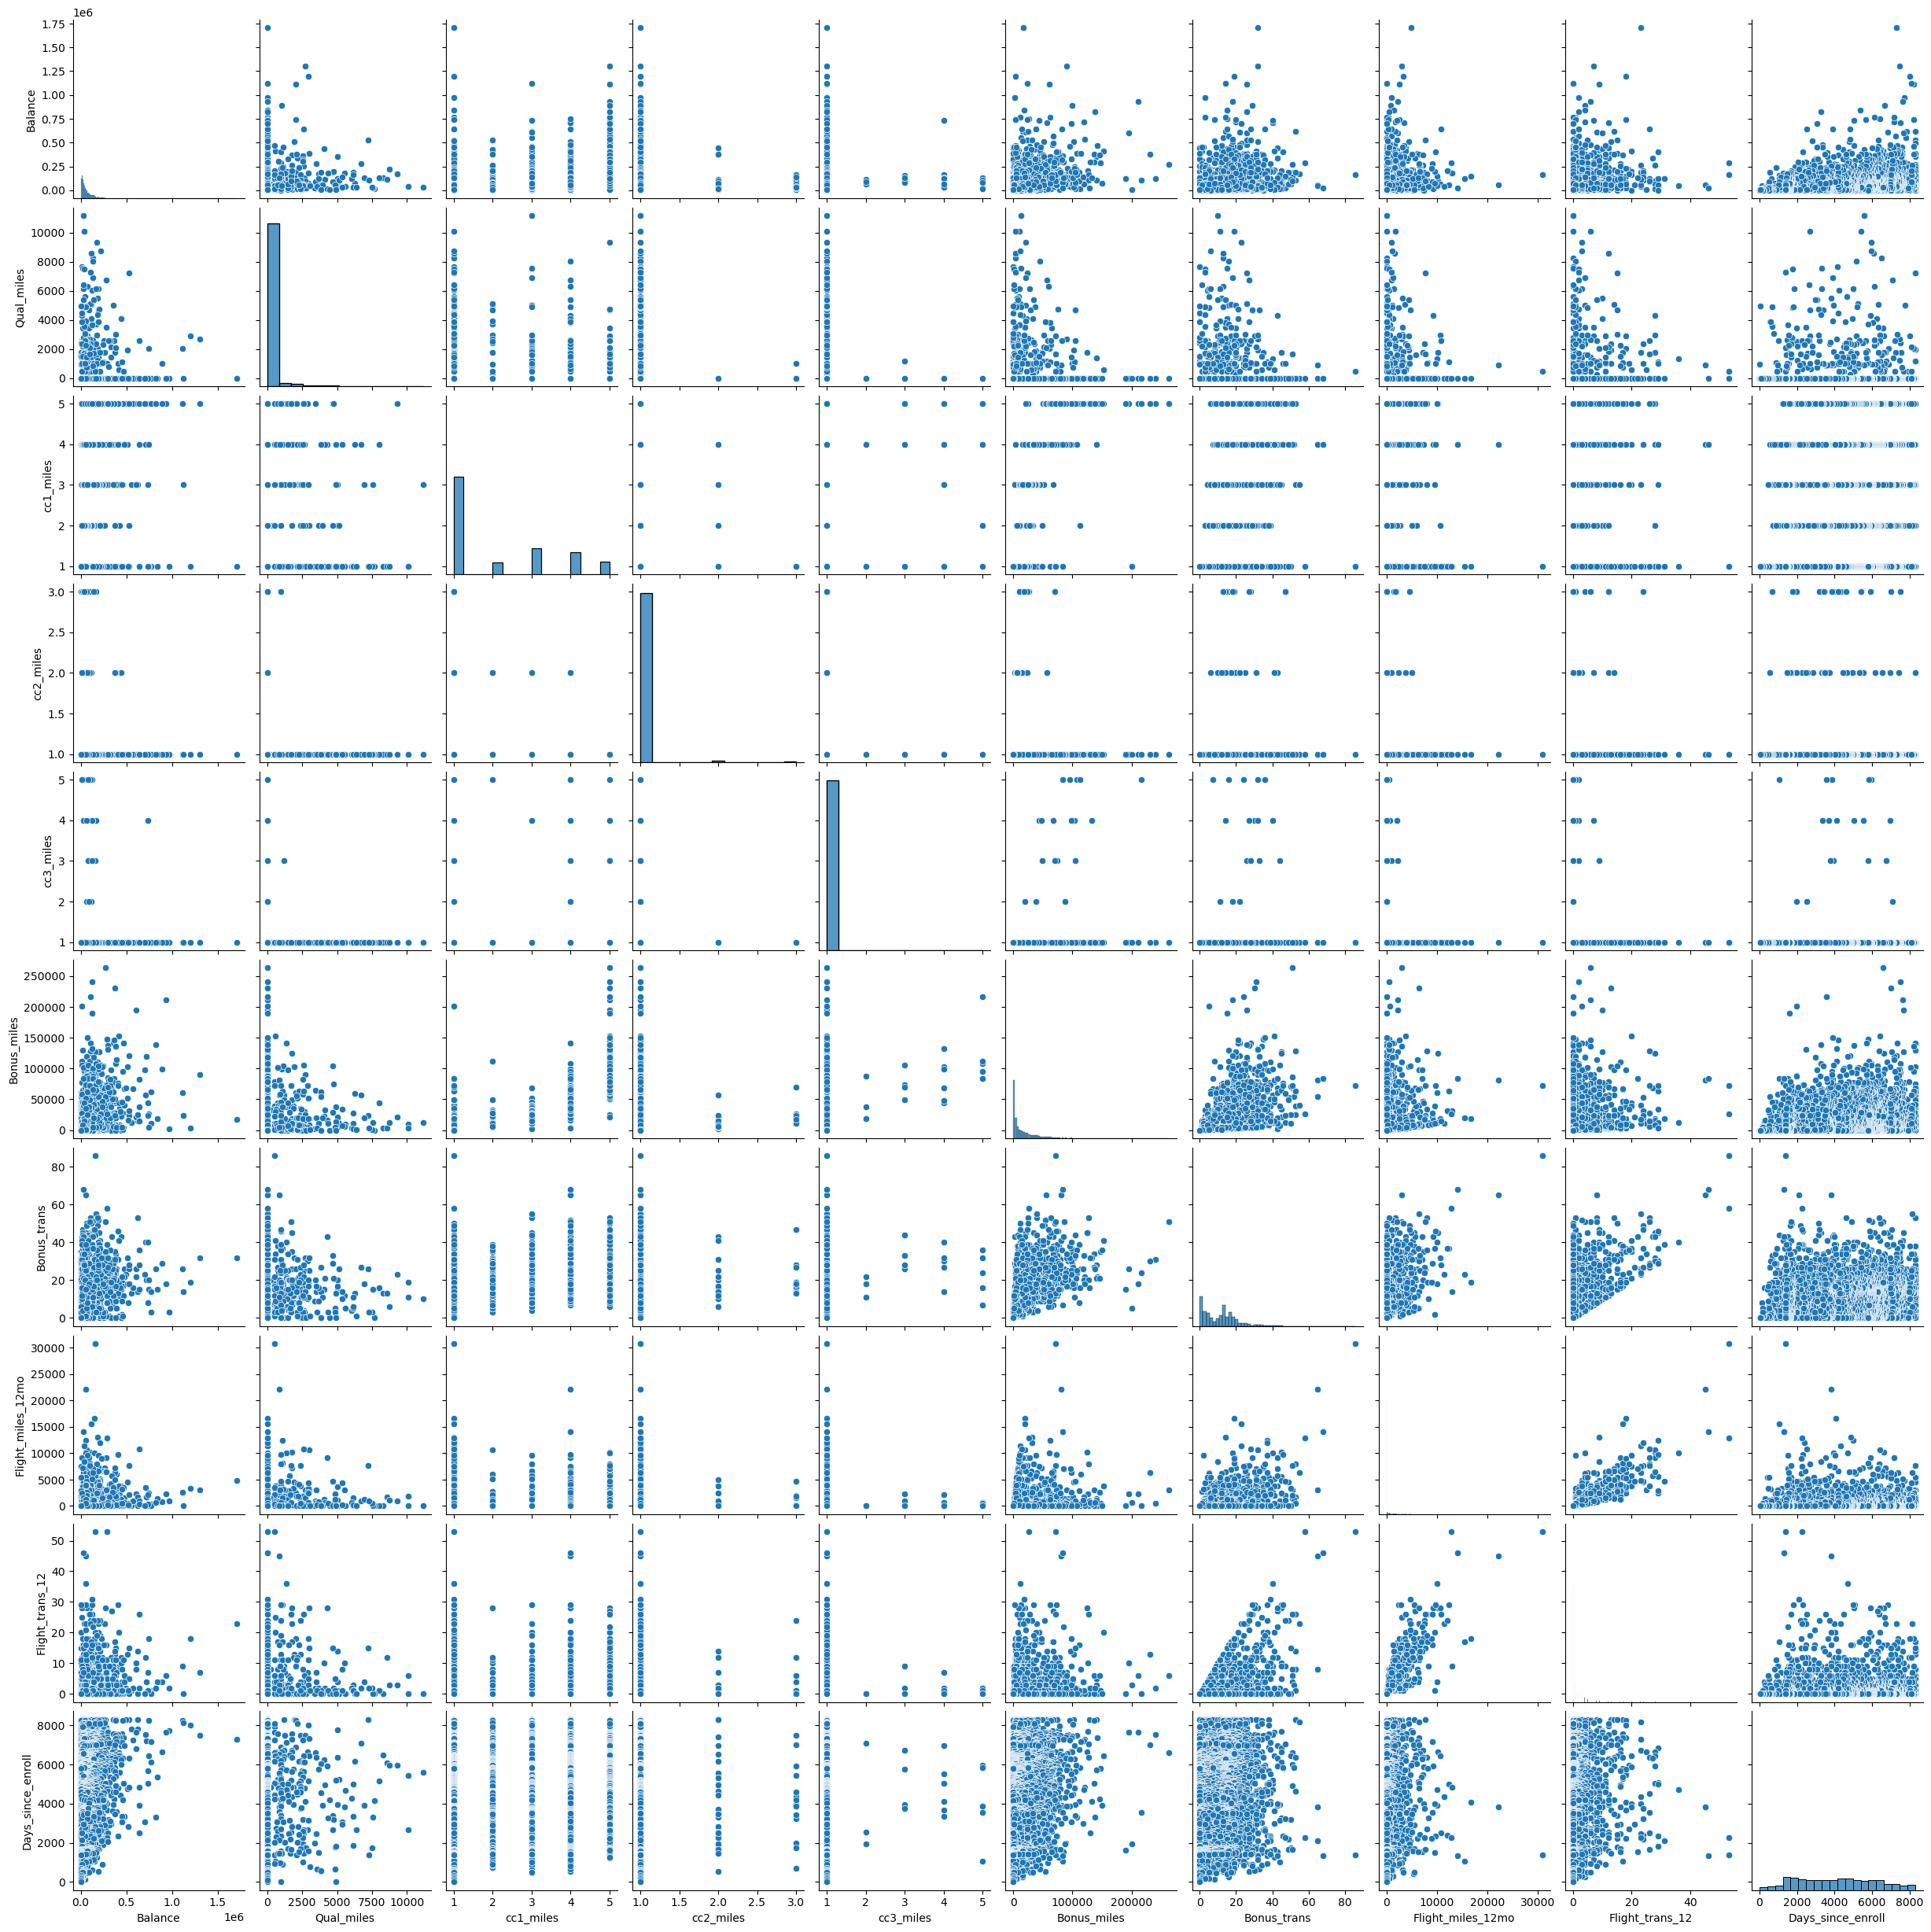

In [62]:
sn.pairplot(data=df)

In [63]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()

In [64]:
df_scale = ss.fit_transform(df)

# K-Means Clustering

In [65]:
from sklearn.cluster import KMeans
wcss =[]
for y in range (1,21):
    km = KMeans(n_clusters=y, random_state=55)
    km.fit(df_scale)
    wcss.append(km.inertia_)

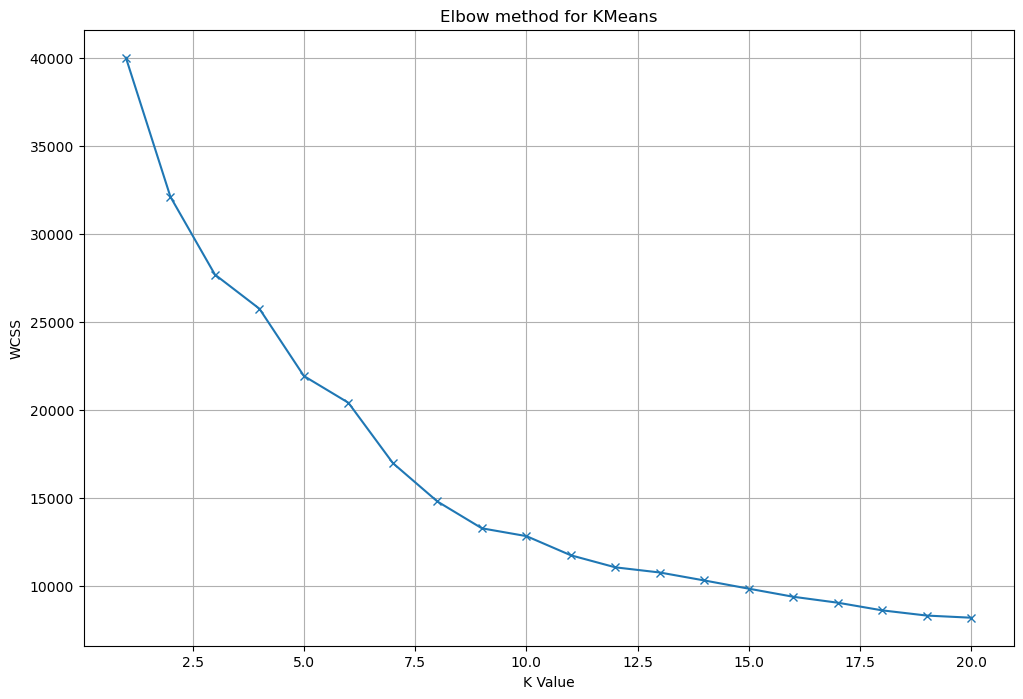

In [66]:
mpt.figure(figsize=(12,8))
mpt.title("Elbow method for KMeans")
mpt.plot(range(1,21), wcss, marker = "x")
mpt.xlabel("K Value")
mpt.ylabel("WCSS")
mpt.grid(True)
mpt.show()

In [67]:
km = KMeans(n_clusters=10, random_state=55)
df["K-Cluster_10"]=km.fit_predict(df_scale)

In [68]:
df["K-Cluster_10"].value_counts()

K-Cluster_10
4    1217
6    1074
5    1002
0     312
1     182
9      72
3      57
2      43
7      25
8      15
Name: count, dtype: int64

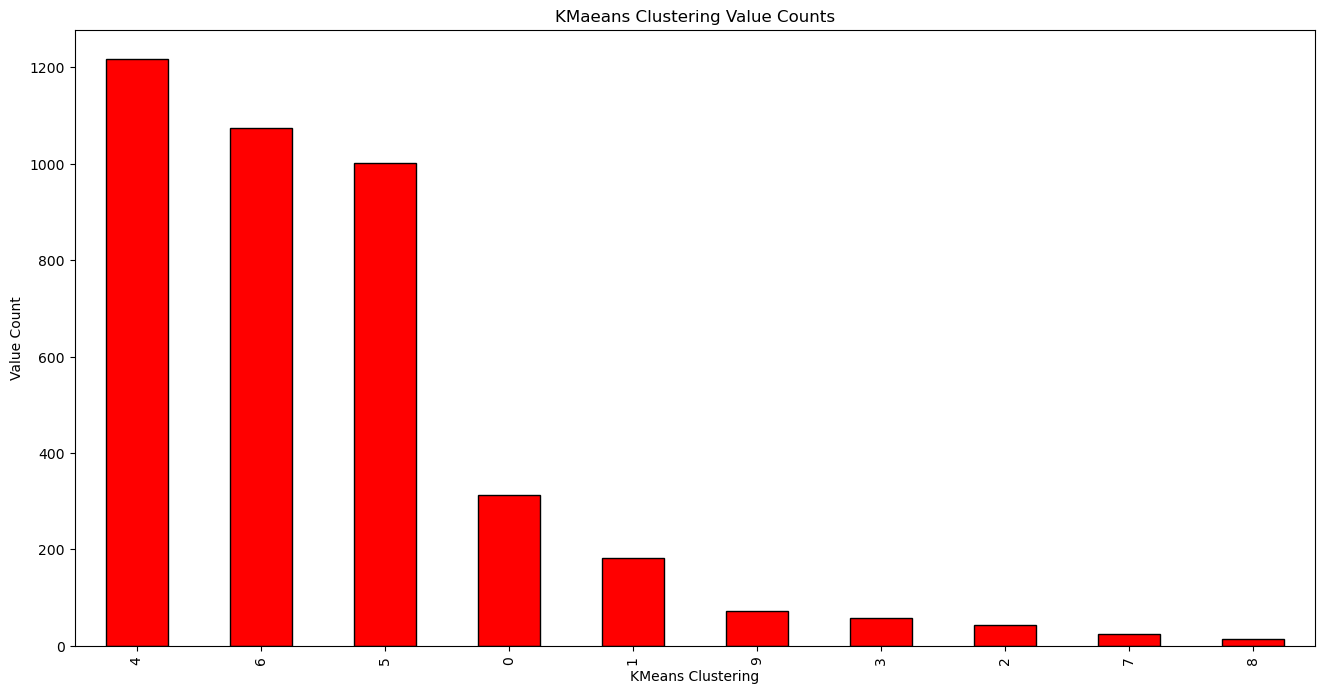

In [69]:
value_counts = df["K-Cluster_10"].value_counts()
mpt.figure(figsize=(16, 8))
value_counts.plot(kind="bar", color="red", edgecolor="black")
mpt.title("KMaeans Clustering Value Counts")
mpt.xlabel("KMeans Clustering")
mpt.ylabel("Value Count")
mpt.show()

In [70]:
km = KMeans(n_clusters=5, random_state=55)
df["K-Cluster_5"]=km.fit_predict(df_scale)

In [71]:
df["K-Cluster_5"].value_counts()

K-Cluster_5
4    1463
2    1184
1    1182
3     155
0      15
Name: count, dtype: int64

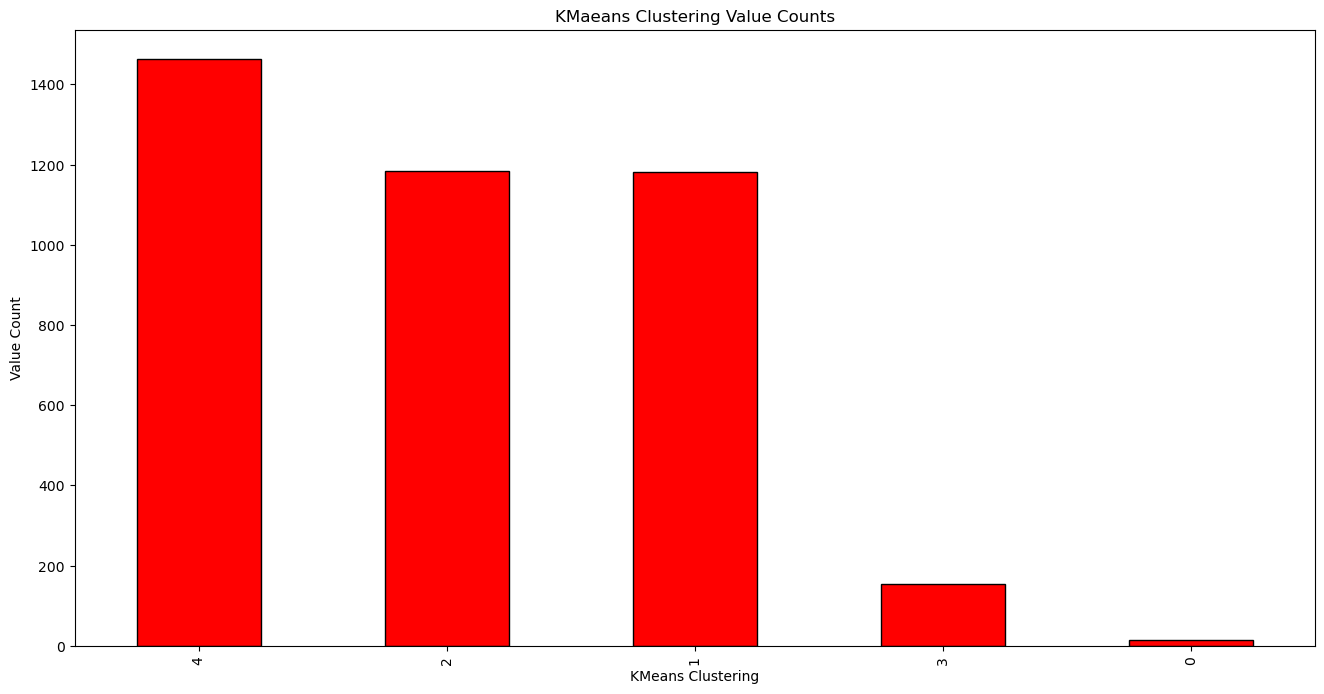

In [72]:
value_counts = df["K-Cluster_5"].value_counts()
mpt.figure(figsize=(16, 8))
value_counts.plot(kind="bar", color="red", edgecolor="black")
mpt.title("KMaeans Clustering Value Counts")
mpt.xlabel("KMeans Clustering")
mpt.ylabel("Value Count")
mpt.show()

In [73]:
km = KMeans(n_clusters=8, random_state=55)
df["K-Cluster_8"]=km.fit_predict(df_scale)

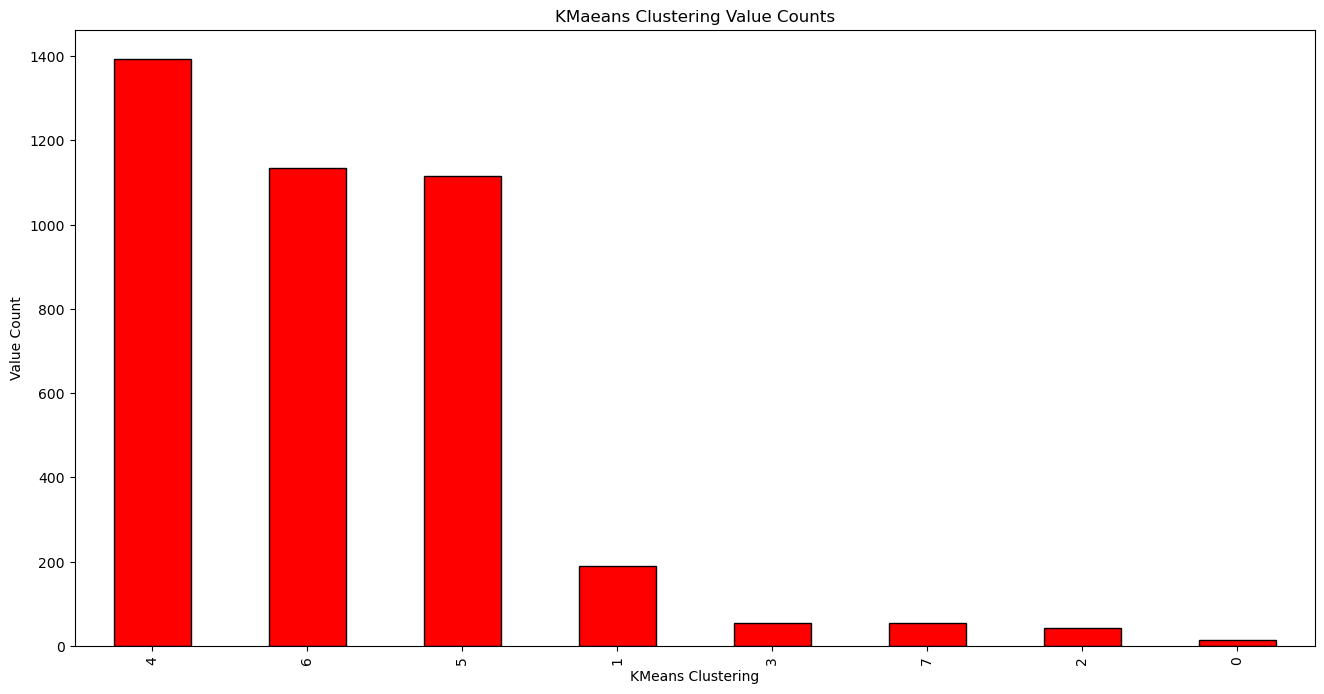

In [74]:
value_counts = df["K-Cluster_8"].value_counts()
mpt.figure(figsize=(16, 8))
value_counts.plot(kind="bar", color="red", edgecolor="black")
mpt.title("KMaeans Clustering Value Counts")
mpt.xlabel("KMeans Clustering")
mpt.ylabel("Value Count")
mpt.show()

In [75]:
from sklearn.metrics import silhouette_score
score = silhouette_score(df_scale, df['K-Cluster_10'])
print(f"Silhouette Score: {score:.2f}")


Silhouette Score: 0.28


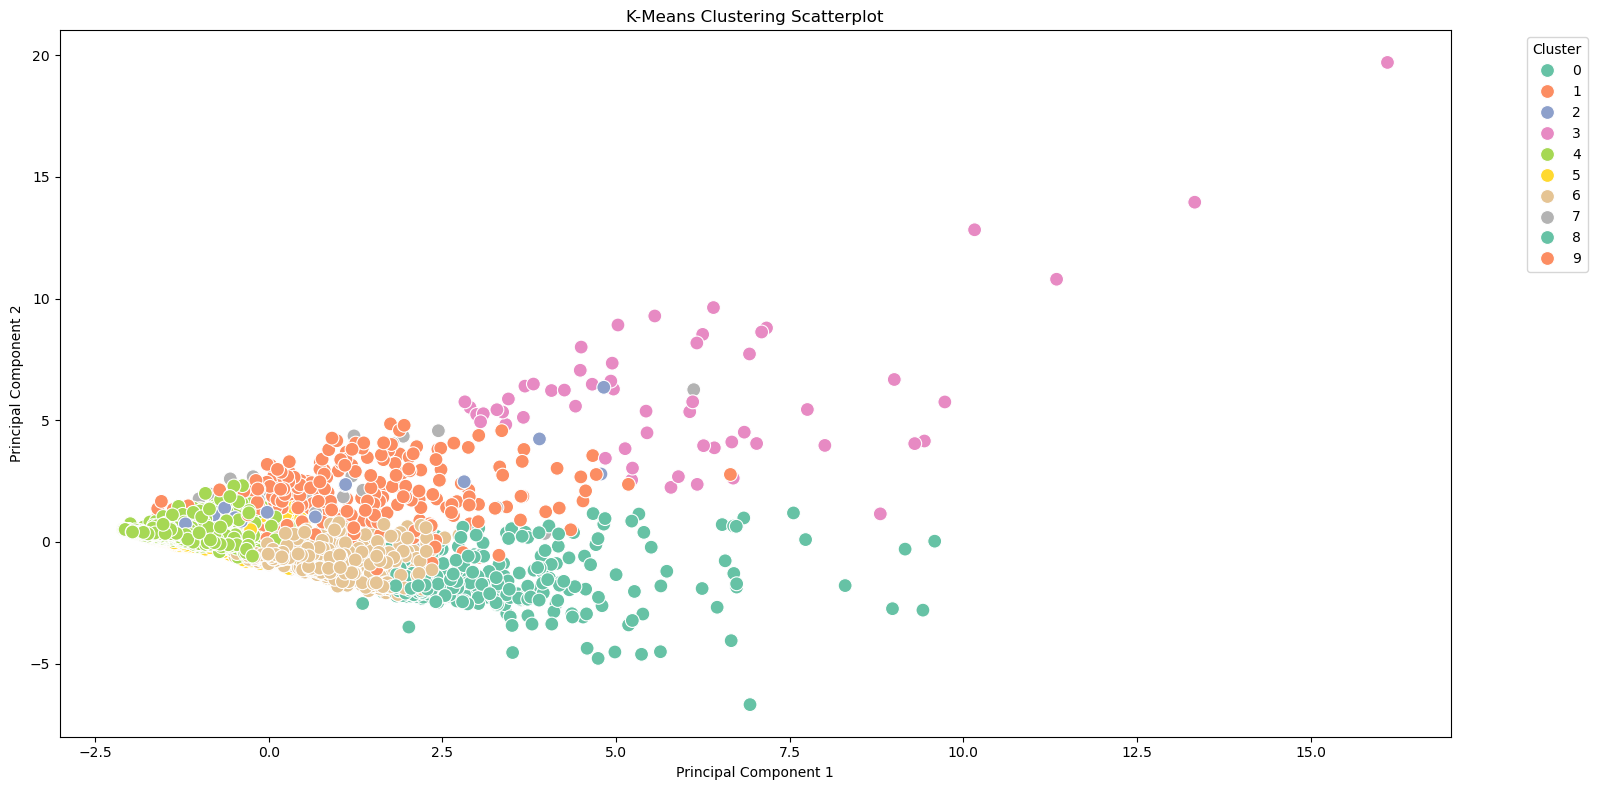

In [76]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scale)
df['PCA1'] = df_pca[:, 0]
df['PCA2'] = df_pca[:, 1]
mpt.figure(figsize=(16,8))
sn.scatterplot(data=df, x='PCA1', y='PCA2', hue='K-Cluster_10', palette='Set2', s=100)
mpt.title("K-Means Clustering Scatterplot")
mpt.xlabel("Principal Component 1")
mpt.ylabel("Principal Component 2")
mpt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
mpt.tight_layout()
mpt.show()



# Hierarchical Clustering

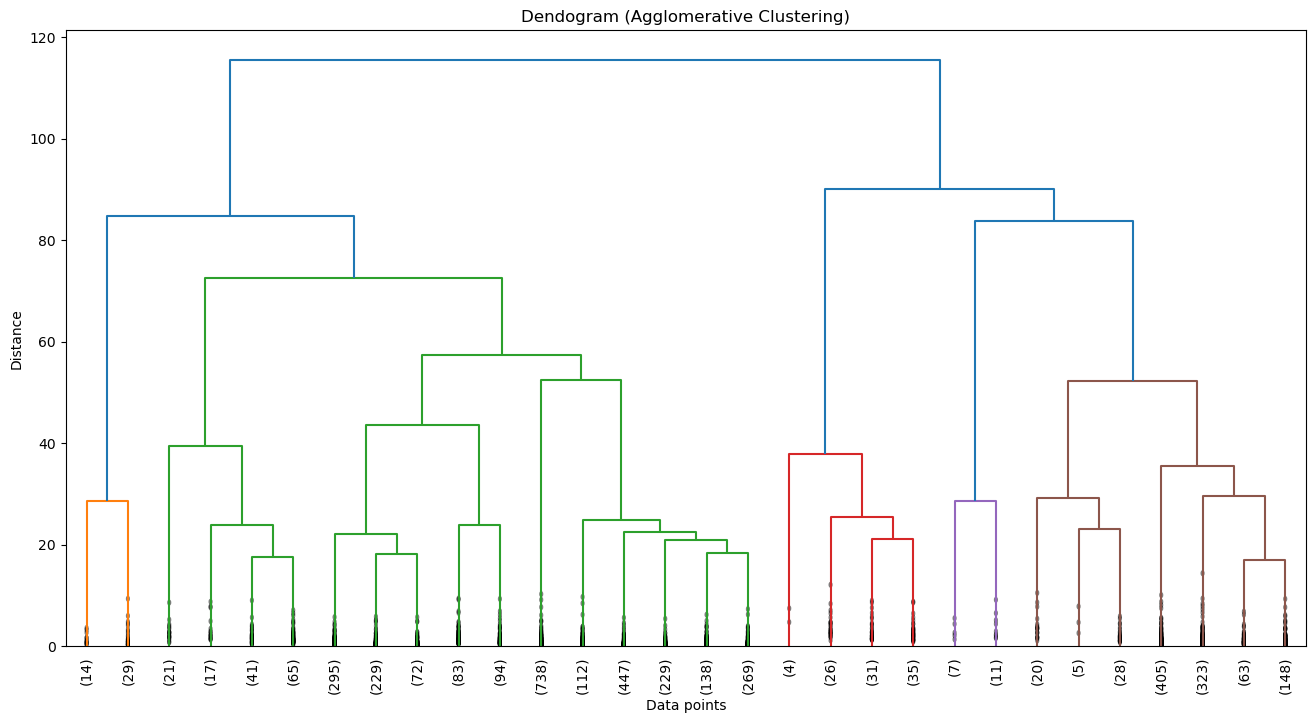

In [77]:
from scipy.cluster.hierarchy import dendrogram, linkage

mpt.figure(figsize=(16,8))
linked = linkage(df_scale, method= "ward")
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
mpt.title("Dendogram (Agglomerative Clustering)")
mpt.xlabel("Data points")
mpt.ylabel("Distance")
mpt.show()

In [78]:
from sklearn.cluster import AgglomerativeClustering
ac = AgglomerativeClustering(n_clusters=5)
df["Agglomertaive Clustering"] = ac.fit_predict(df_scale)

In [79]:
df["Agglomertaive Clustering"].value_counts()

Agglomertaive Clustering
0    2850
1     992
2      96
3      43
4      18
Name: count, dtype: int64

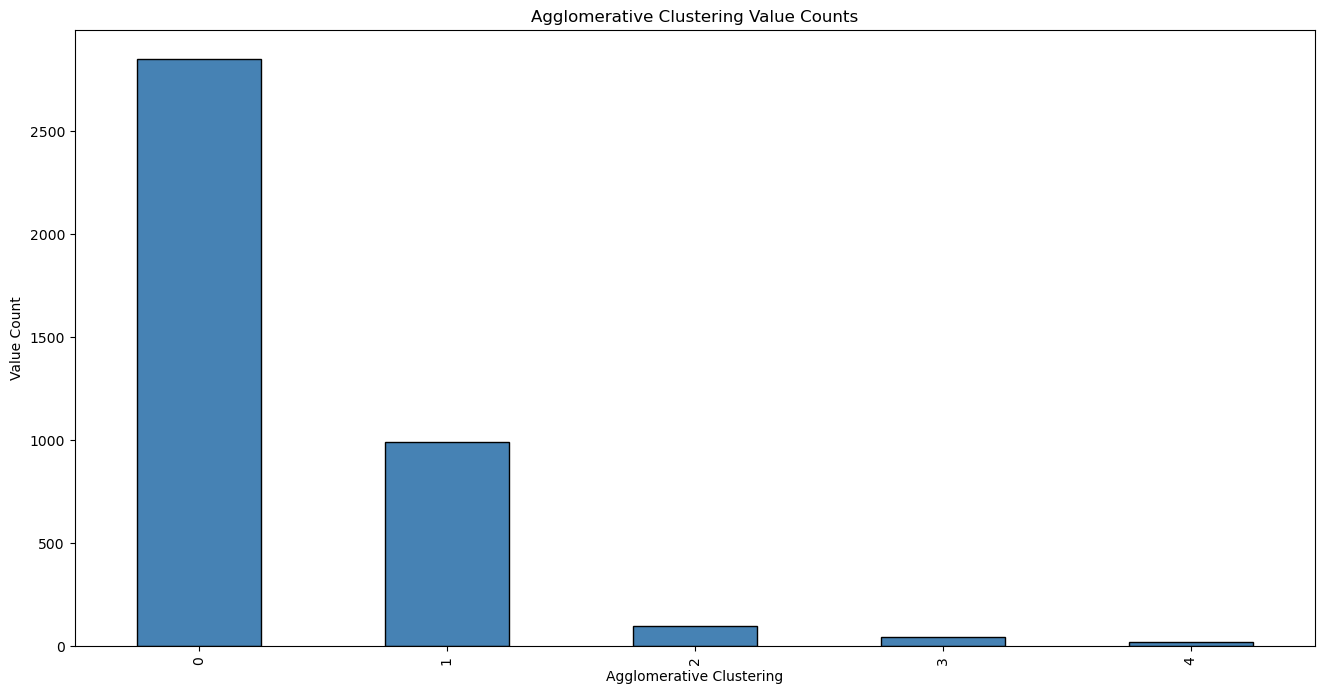

In [80]:
value_counts = df["Agglomertaive Clustering"].value_counts()
mpt.figure(figsize=(16, 8))
value_counts.plot(kind="bar", color="steelblue", edgecolor="black")
mpt.title("Agglomerative Clustering Value Counts")
mpt.xlabel("Agglomerative Clustering")
mpt.ylabel("Value Count")
mpt.show()


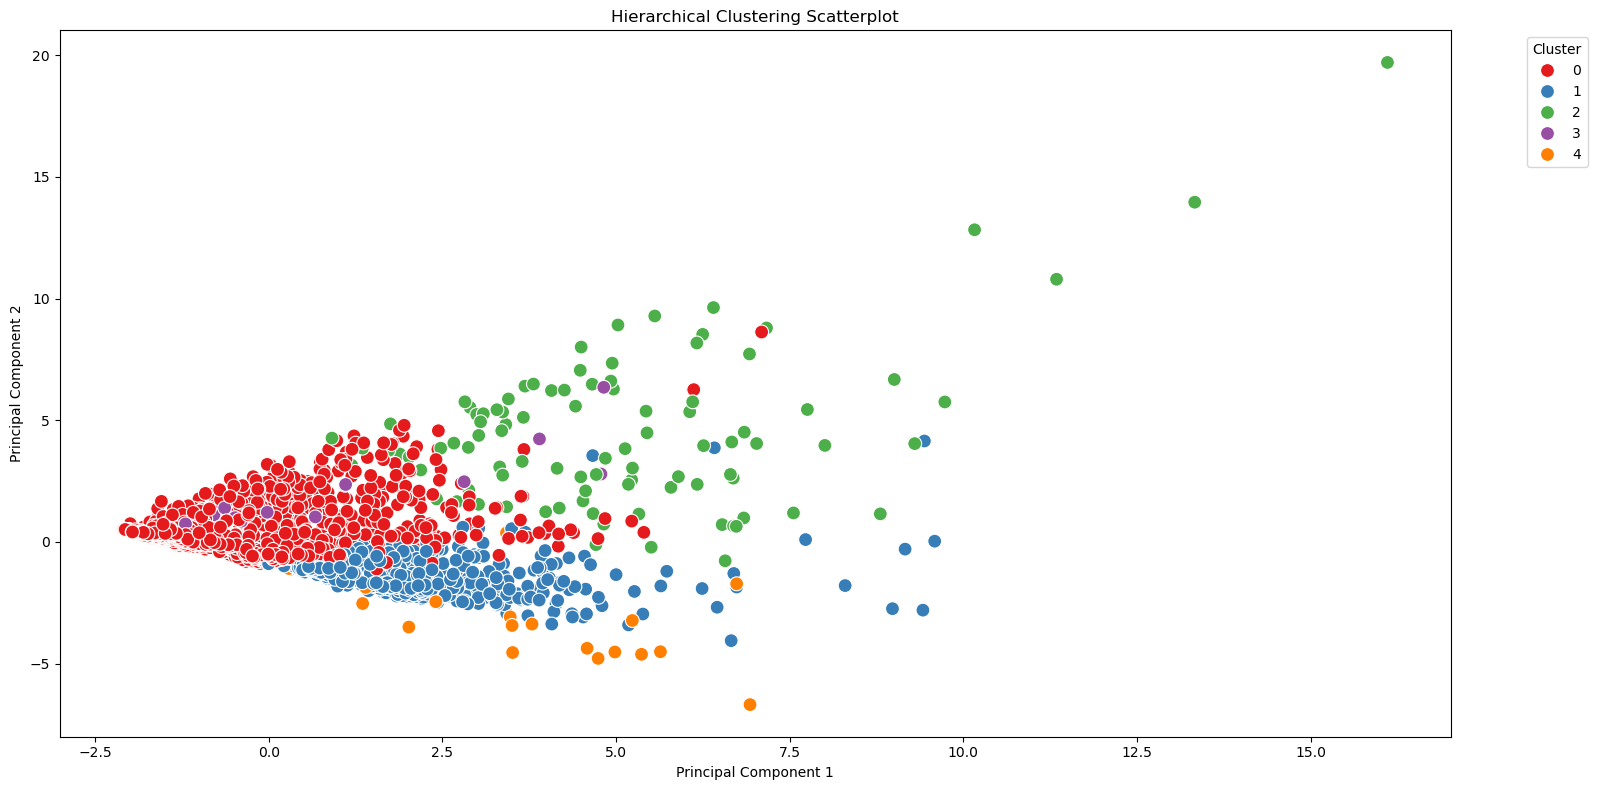

In [81]:
mpt.figure(figsize=(16,8))
sn.scatterplot(data=df, x='PCA1', y='PCA2', hue='Agglomertaive Clustering', palette='Set1', s=100)
mpt.title("Hierarchical Clustering Scatterplot")
mpt.xlabel("Principal Component 1")
mpt.ylabel("Principal Component 2")
mpt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
mpt.tight_layout()
mpt.show()


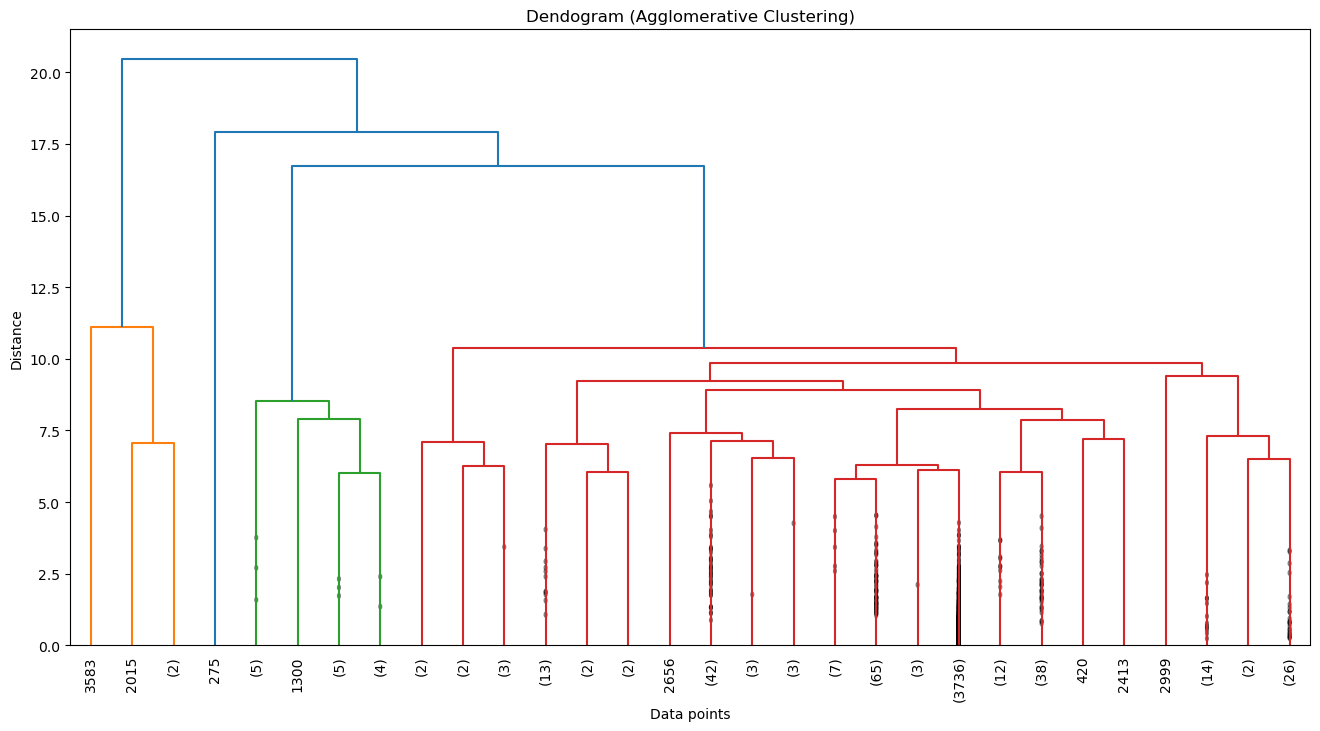

In [82]:
mpt.figure(figsize=(16,8))
linked = linkage(df_scale, method= "average")
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
mpt.title("Dendogram (Agglomerative Clustering)")
mpt.xlabel("Data points")
mpt.ylabel("Distance")
mpt.show()

In [83]:
from sklearn.cluster import AgglomerativeClustering
ac = AgglomerativeClustering(n_clusters=5)
df["Agglomertaive Clustering_avg"] = ac.fit_predict(df_scale)

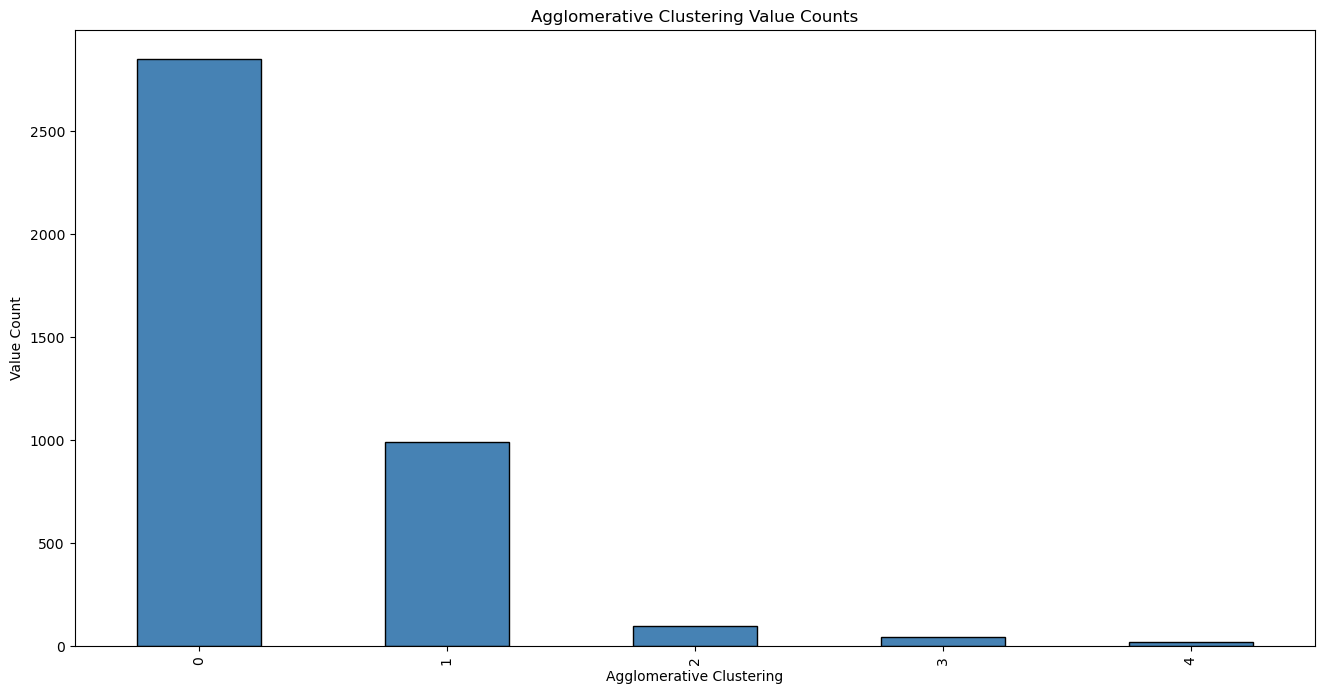

In [84]:
value_counts = df["Agglomertaive Clustering_avg"].value_counts()
mpt.figure(figsize=(16, 8))
value_counts.plot(kind="bar", color="steelblue", edgecolor="black")
mpt.title("Agglomerative Clustering Value Counts")
mpt.xlabel("Agglomerative Clustering")
mpt.ylabel("Value Count")
mpt.show()

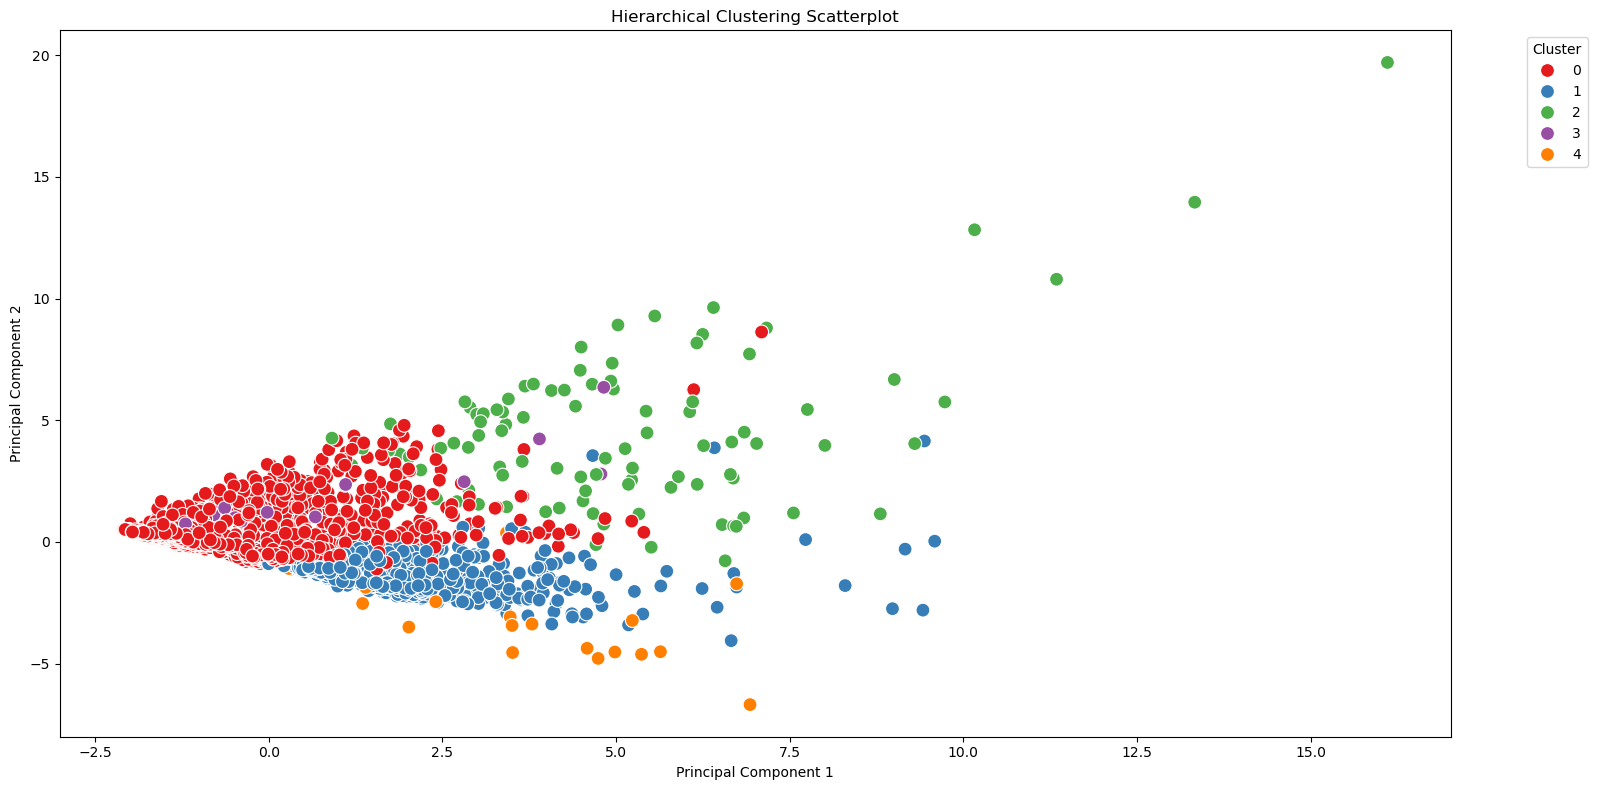

In [85]:
mpt.figure(figsize=(16,8))
sn.scatterplot(data=df, x='PCA1', y='PCA2', hue='Agglomertaive Clustering_avg', palette='Set1', s=100)
mpt.title("Hierarchical Clustering Scatterplot")
mpt.xlabel("Principal Component 1")
mpt.ylabel("Principal Component 2")
mpt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
mpt.tight_layout()
mpt.show()

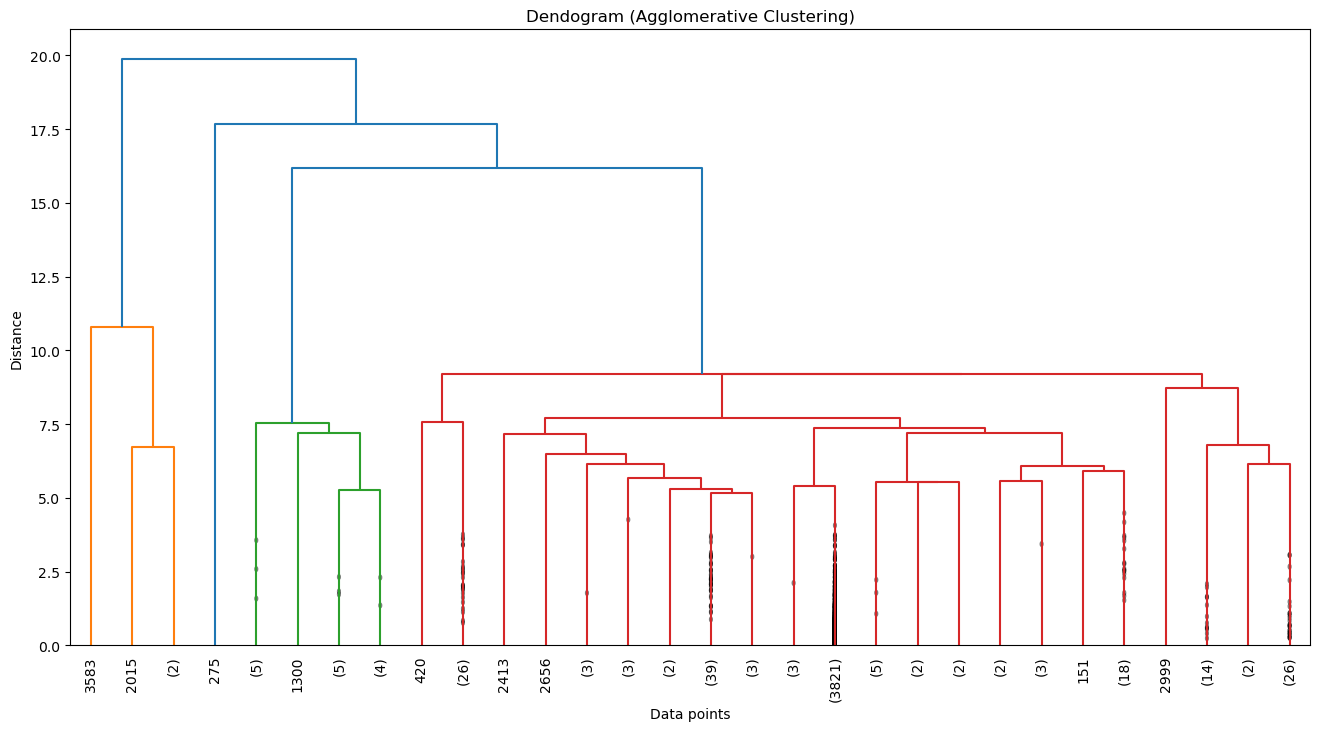

In [86]:
mpt.figure(figsize=(16,8))
linked = linkage(df_scale, method= "centroid")
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
mpt.title("Dendogram (Agglomerative Clustering)")
mpt.xlabel("Data points")
mpt.ylabel("Distance")
mpt.show()

In [87]:
from sklearn.cluster import AgglomerativeClustering
ac = AgglomerativeClustering(n_clusters=5)
df["Agglomertaive Clustering_cen"] = ac.fit_predict(df_scale)

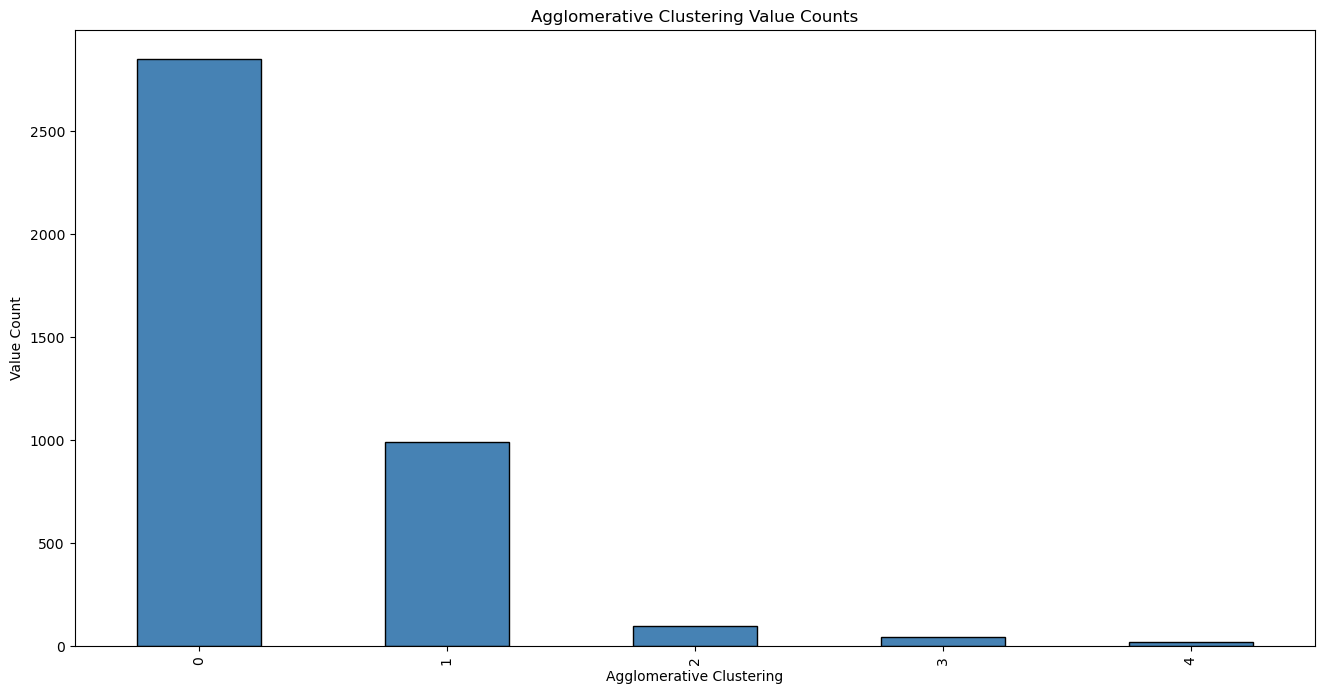

In [88]:
value_counts = df["Agglomertaive Clustering_cen"].value_counts()
mpt.figure(figsize=(16, 8))
value_counts.plot(kind="bar", color="steelblue", edgecolor="black")
mpt.title("Agglomerative Clustering Value Counts")
mpt.xlabel("Agglomerative Clustering")
mpt.ylabel("Value Count")
mpt.show()

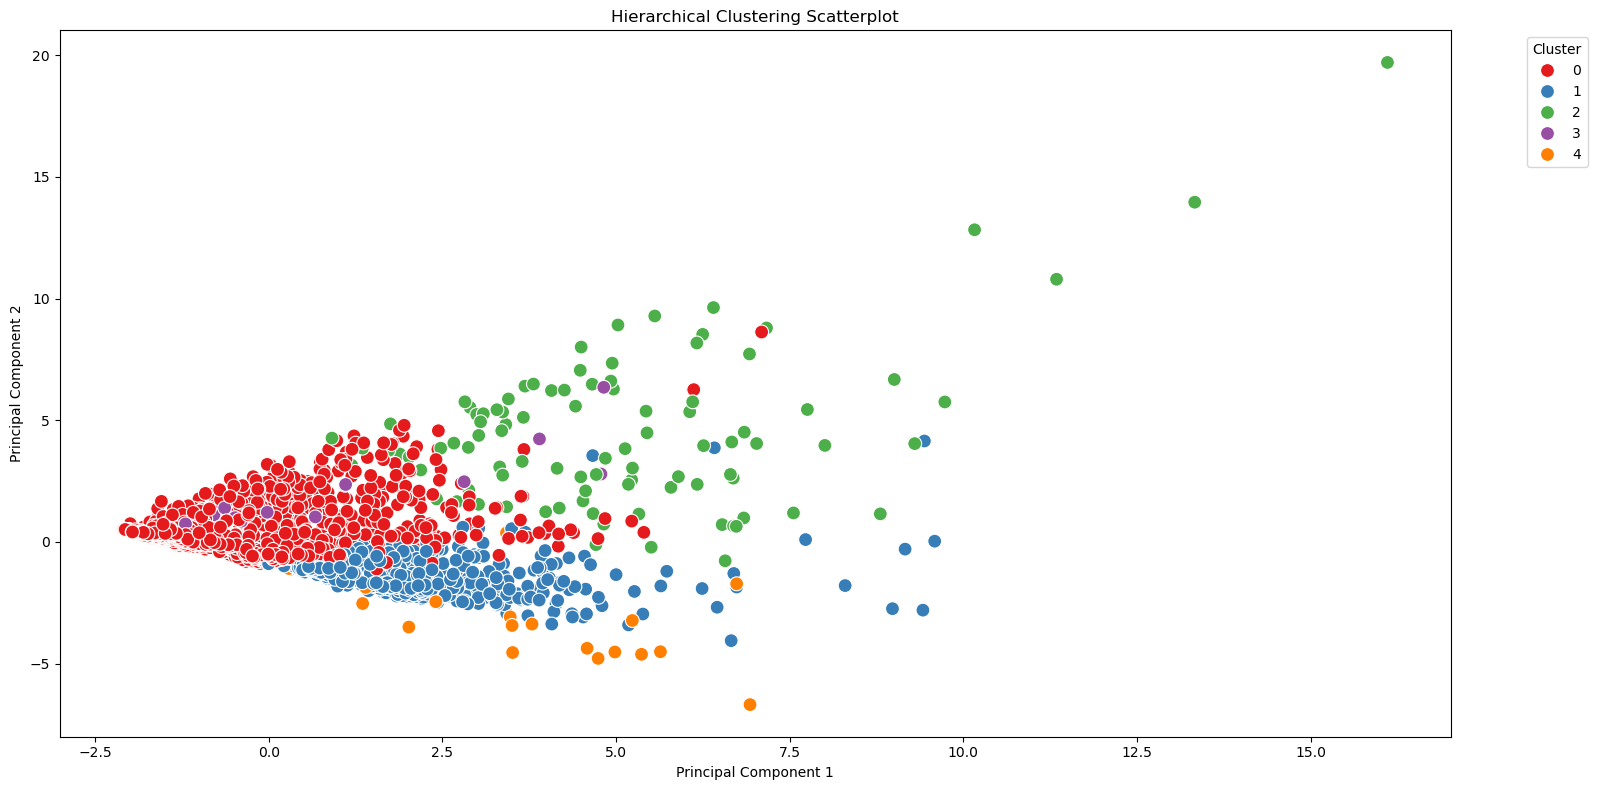

In [89]:
mpt.figure(figsize=(16,8))
sn.scatterplot(data=df, x='PCA1', y='PCA2', hue='Agglomertaive Clustering_cen', palette='Set1', s=100)
mpt.title("Hierarchical Clustering Scatterplot")
mpt.xlabel("Principal Component 1")
mpt.ylabel("Principal Component 2")
mpt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
mpt.tight_layout()
mpt.show()

# DBScan

In [90]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [91]:
nn = NearestNeighbors(n_neighbors=5)
nn_fit = nn.fit(df_scale)
distance, indices = nn_fit.kneighbors(df_scale)

In [92]:
indices[-1]

array([3998, 3491, 3455, 3449, 3981], dtype=int64)

In [93]:
distance = distance[:,3]

In [94]:
distance = np.sort(distance)
distance

array([1.08829090e-02, 1.22819759e-02, 1.24696974e-02, ...,
       8.09543658e+00, 8.34937995e+00, 1.33627651e+01])

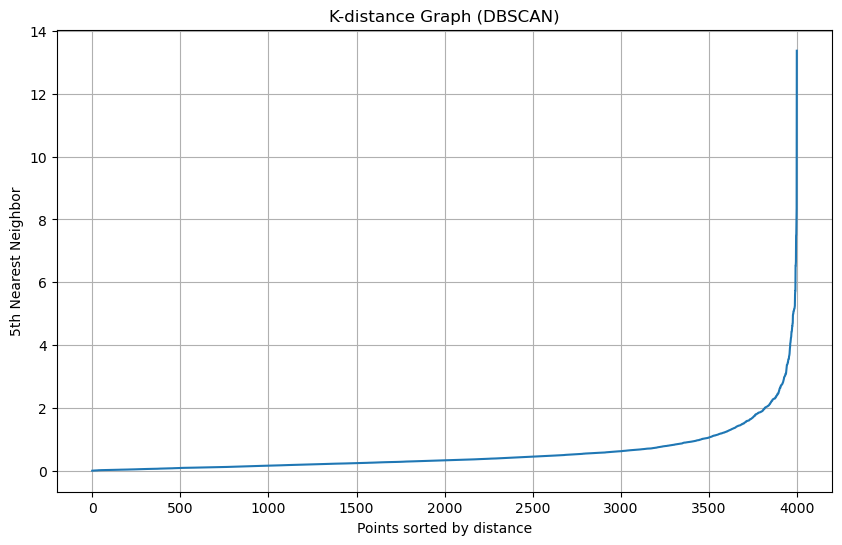

In [95]:
mpt.figure(figsize=(10,6))
mpt.plot(distance)
mpt.title("K-distance Graph (DBSCAN)")
mpt.xlabel("Points sorted by distance")
mpt.ylabel("5th Nearest Neighbor")
mpt.grid(True)
mpt.show()

In [96]:
dbs = DBSCAN(eps= 2)
dbs.fit_predict(df_scale)

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [97]:
df["DBSCAN Cluster"] = dbs.fit_predict(df_scale)

In [98]:
df["DBSCAN Cluster"].value_counts()

DBSCAN Cluster
 0    3814
-1     146
 2      23
 1      13
 3       3
Name: count, dtype: int64

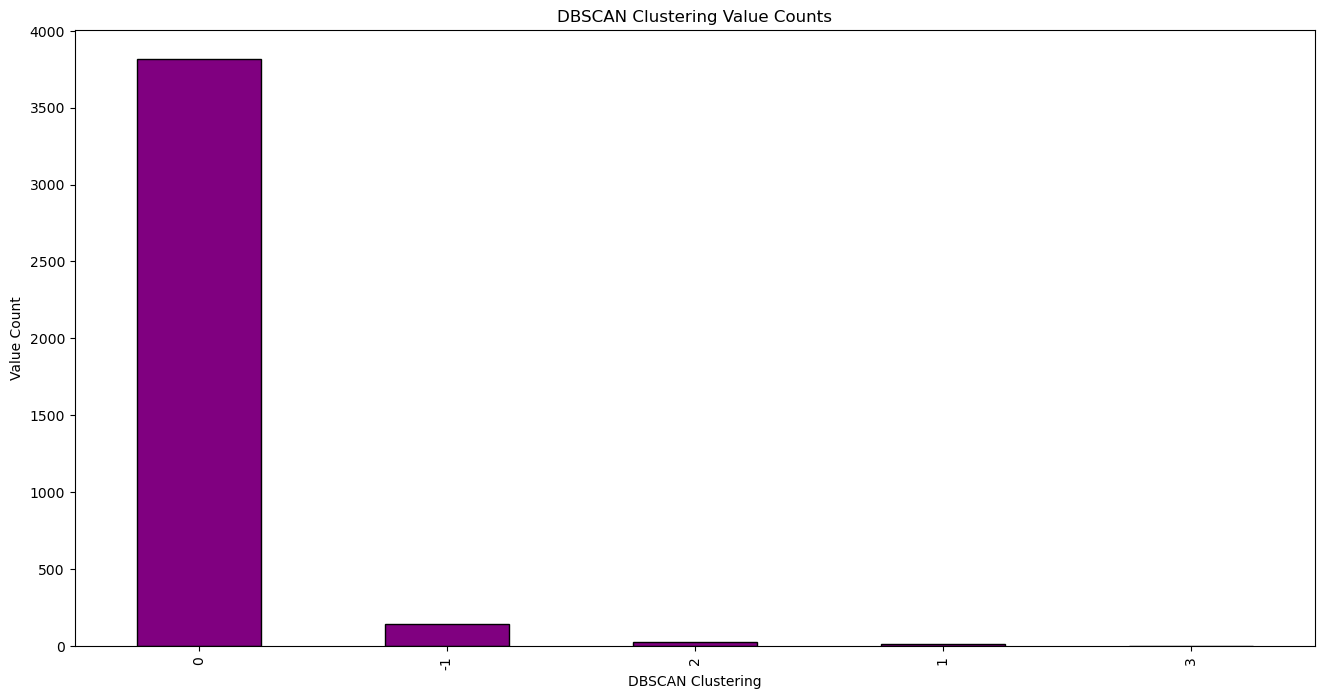

In [99]:
value_counts = df["DBSCAN Cluster"].value_counts()
mpt.figure(figsize=(16, 8))
value_counts.plot(kind="bar", color="purple", edgecolor="black")
mpt.title("DBSCAN Clustering Value Counts")
mpt.xlabel("DBSCAN Clustering")
mpt.ylabel("Value Count")
mpt.show()

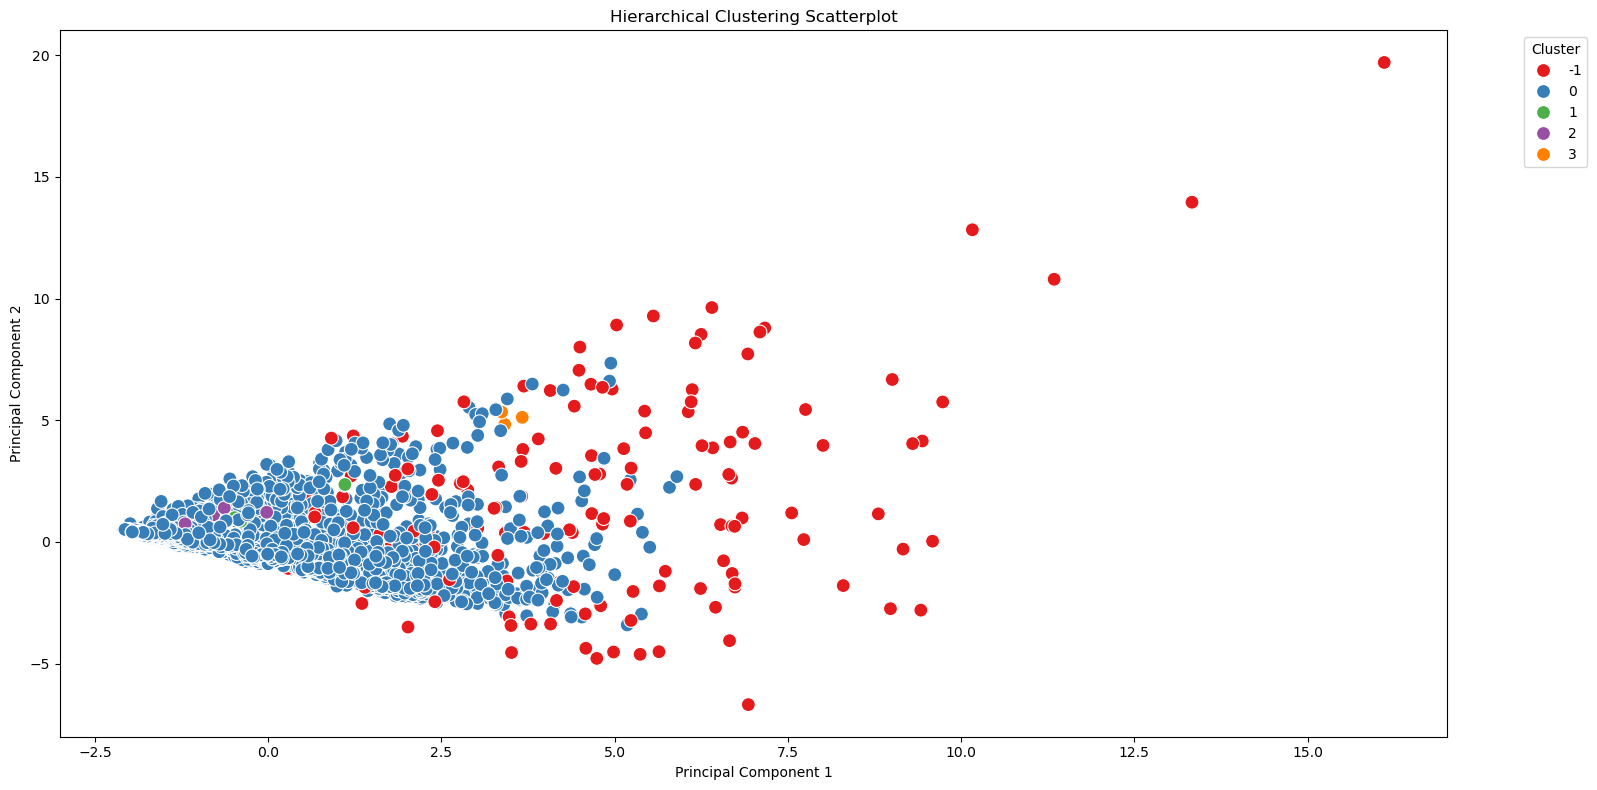

In [100]:
mpt.figure(figsize=(16,8))
sn.scatterplot(data=df, x='PCA1', y='PCA2', hue='DBSCAN Cluster', palette='Set1', s=100)
mpt.title("Hierarchical Clustering Scatterplot")
mpt.xlabel("Principal Component 1")
mpt.ylabel("Principal Component 2")
mpt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
mpt.tight_layout()
mpt.show()

In [101]:
dbs = DBSCAN(eps= 1.5)
dbs.fit_predict(df_scale)

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [102]:
df["DBSCAN Cluster_1.5"] = dbs.fit_predict(df_scale)

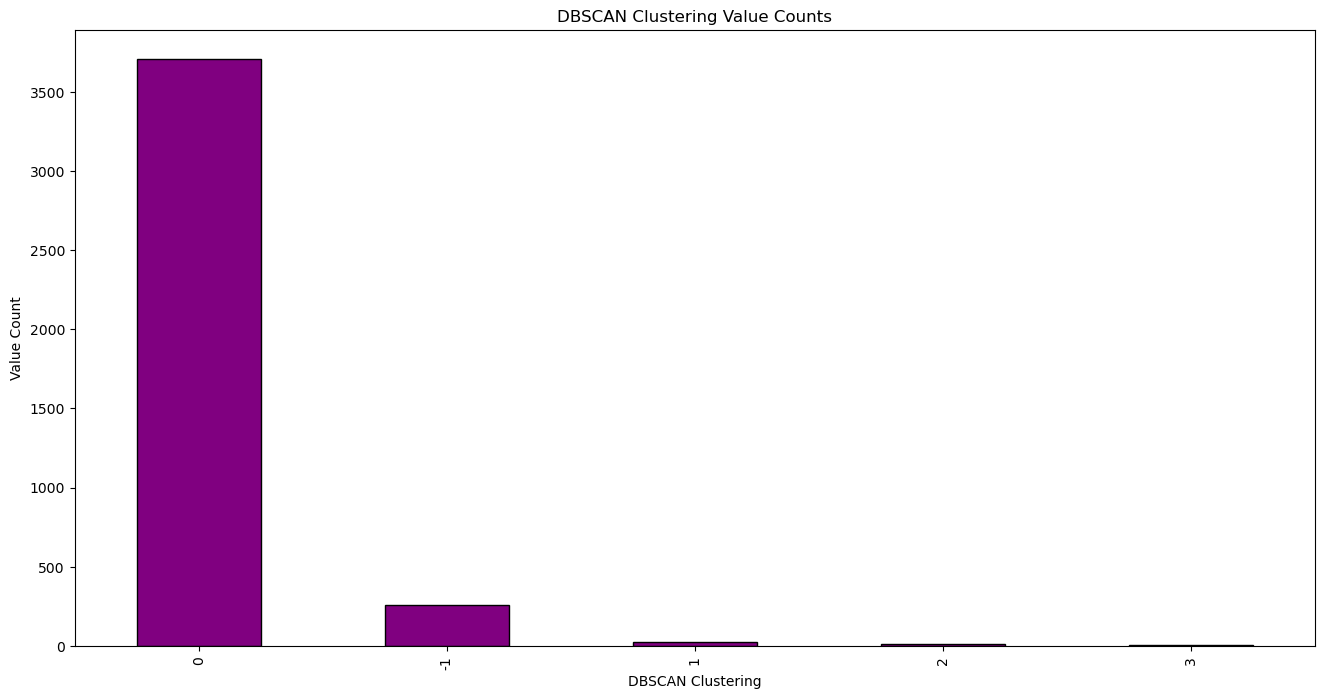

In [103]:
value_counts = df["DBSCAN Cluster_1.5"].value_counts()
mpt.figure(figsize=(16, 8))
value_counts.plot(kind="bar", color="purple", edgecolor="black")
mpt.title("DBSCAN Clustering Value Counts")
mpt.xlabel("DBSCAN Clustering")
mpt.ylabel("Value Count")
mpt.show()

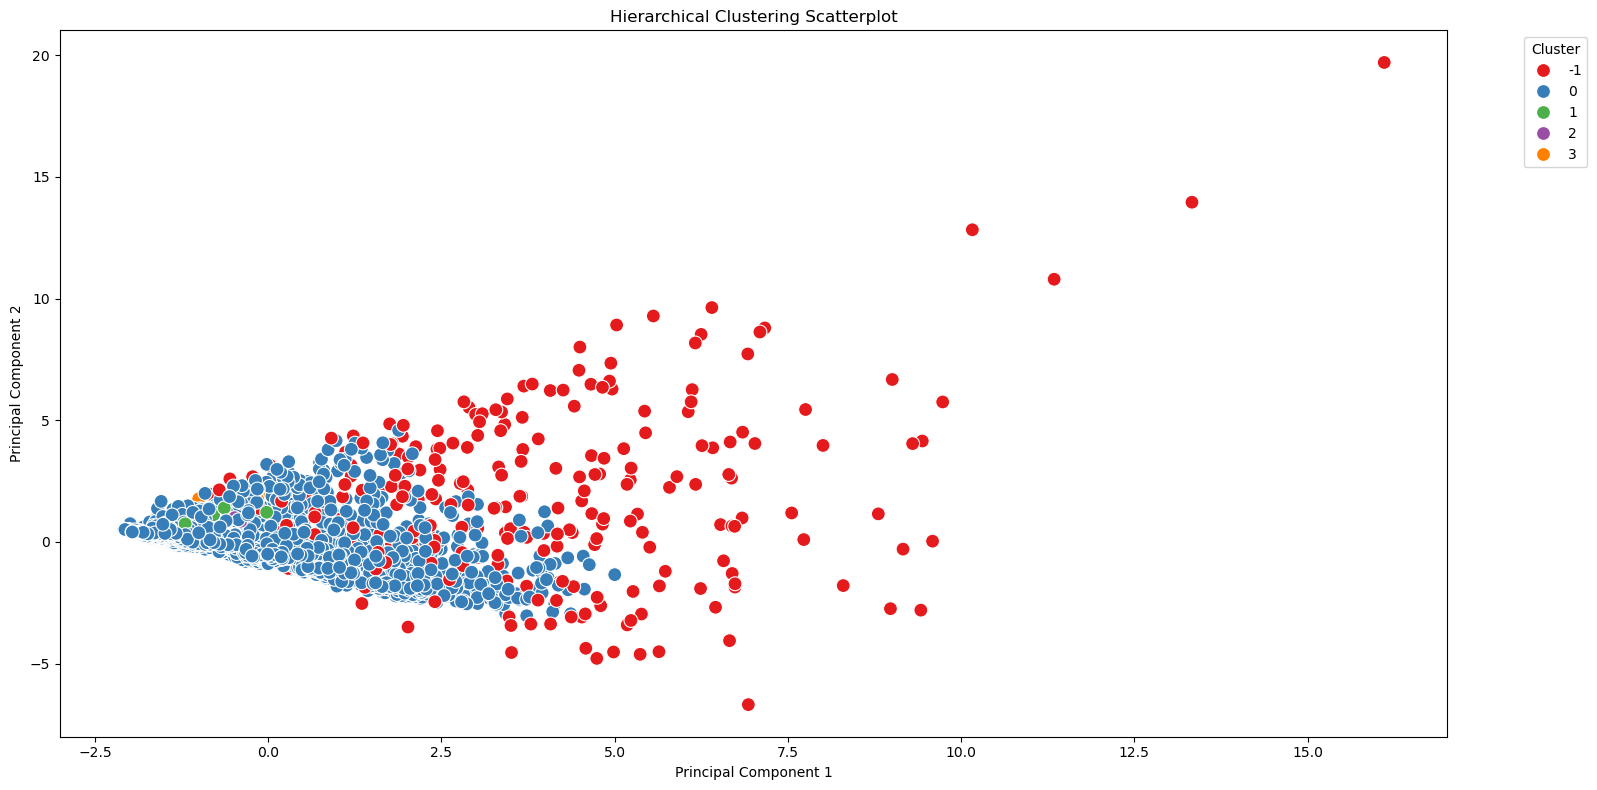

In [104]:
mpt.figure(figsize=(16,8))
sn.scatterplot(data=df, x='PCA1', y='PCA2', hue='DBSCAN Cluster_1.5', palette='Set1', s=100)
mpt.title("Hierarchical Clustering Scatterplot")
mpt.xlabel("Principal Component 1")
mpt.ylabel("Principal Component 2")
mpt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
mpt.tight_layout()
mpt.show()

In [106]:
dbs = DBSCAN(eps= 1)
dbs.fit_predict(df_scale)
df["DBSCAN Cluster_1"] = dbs.fit_predict(df_scale)

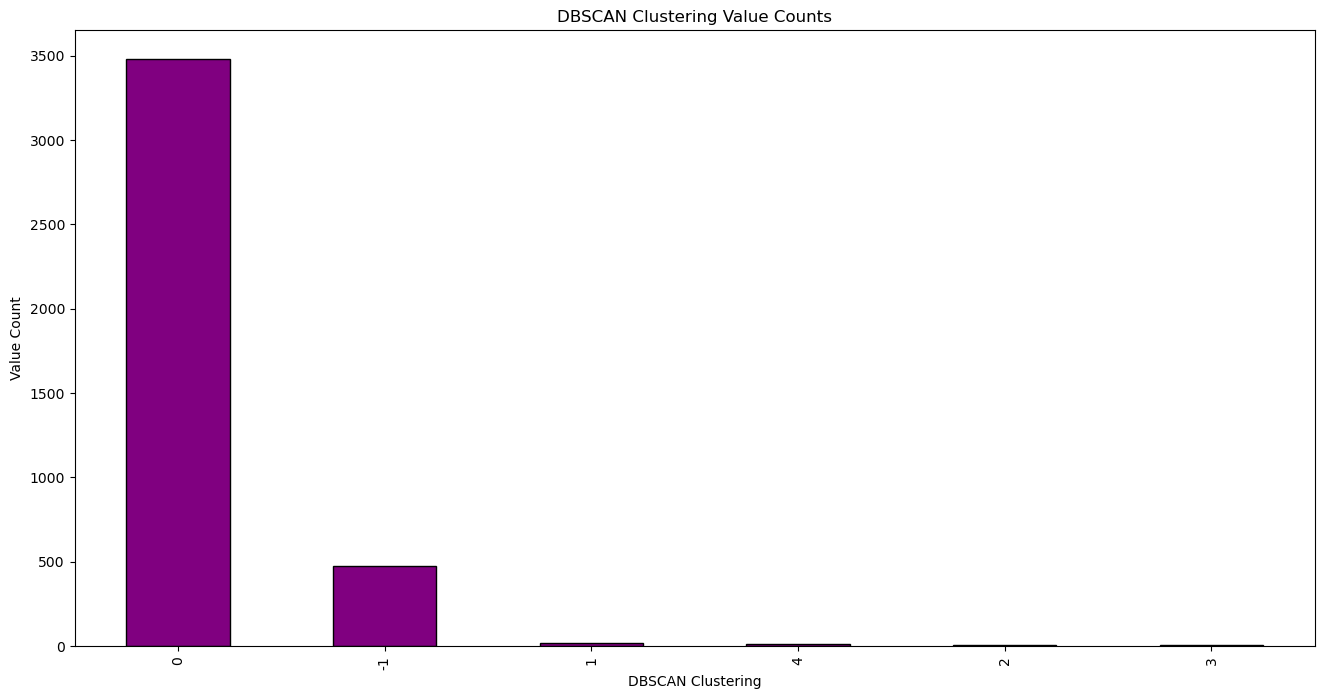

In [107]:
value_counts = df["DBSCAN Cluster_1"].value_counts()
mpt.figure(figsize=(16, 8))
value_counts.plot(kind="bar", color="purple", edgecolor="black")
mpt.title("DBSCAN Clustering Value Counts")
mpt.xlabel("DBSCAN Clustering")
mpt.ylabel("Value Count")
mpt.show()

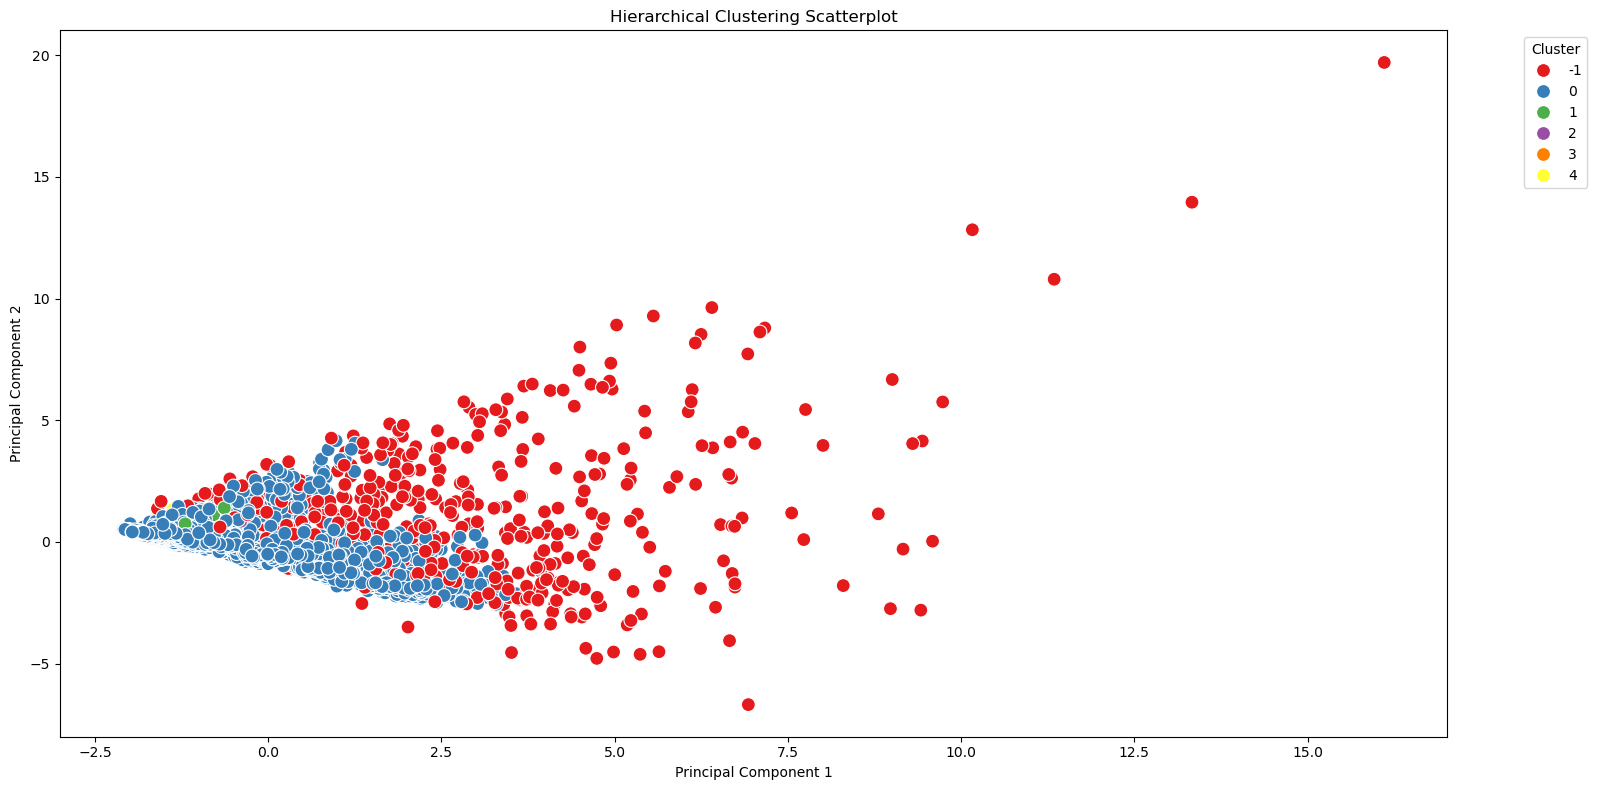

In [108]:
mpt.figure(figsize=(16,8))
sn.scatterplot(data=df, x='PCA1', y='PCA2', hue='DBSCAN Cluster_1', palette='Set1', s=100)
mpt.title("Hierarchical Clustering Scatterplot")
mpt.xlabel("Principal Component 1")
mpt.ylabel("Principal Component 2")
mpt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
mpt.tight_layout()
mpt.show()